In [1]:
import pandas as pd

df_zap = pd.read_csv('zap_data_22.csv')
df_calib = pd.read_csv('calib.csv')

print(df_zap)
print(df_calib)

              lat        lon   timestamp  speed  voltage  \
0             NaN        NaN  1704056413    NaN    25.20   
1             NaN        NaN  1704056636    NaN    25.20   
2             NaN        NaN  1704056661    NaN    25.20   
3             NaN        NaN  1704056751    NaN    25.20   
4             NaN        NaN  1704056727    NaN    25.20   
...           ...        ...         ...    ...      ...   
161529  56.070923  37.123569  1735678101    0.0    25.35   
161530  56.070923  37.123569  1735678251    0.0    25.35   
161531  56.070923  37.123569  1735678401    0.0    25.35   
161532  56.070923  37.123569  1735678551    0.0    25.35   
161533  56.070923  37.123569  1735678700    0.0    25.35   

                                                 can_data  
0                        {"LLS_0": 1477, "xLLS_71": 1477}  
1                        {"LLS_0": 1477, "xLLS_71": 1477}  
2                        {"LLS_0": 1477, "xLLS_71": 1477}  
3                        {"LLS_0": 1477

интерполяция

3

in out

1   2

2   3

4   5

1 -> 2

2 -> 3

3 -> 4

4 -> 5

In [2]:
import json

# Сначала преобразуем строковые представления словарей в реальные словари Python
df_zap['data'] = df_zap['can_data'].apply(lambda x: json.loads(x))

# Теперь создаем новый столбец LLS, извлекая значение LLS_0
df_zap['LLS'] = df_zap['data'].apply(lambda x: x.get('LLS_0'))

# Если нужно, можно удалить промежуточный столбец data
df_zap.drop(columns=['data'], inplace=True)
df_zap.drop(columns=['can_data'], inplace=True)

In [3]:
print(df_zap)

              lat        lon   timestamp  speed  voltage     LLS
0             NaN        NaN  1704056413    NaN    25.20  1477.0
1             NaN        NaN  1704056636    NaN    25.20  1477.0
2             NaN        NaN  1704056661    NaN    25.20  1477.0
3             NaN        NaN  1704056751    NaN    25.20  1477.0
4             NaN        NaN  1704056727    NaN    25.20  1477.0
...           ...        ...         ...    ...      ...     ...
161529  56.070923  37.123569  1735678101    0.0    25.35  3345.0
161530  56.070923  37.123569  1735678251    0.0    25.35  3345.0
161531  56.070923  37.123569  1735678401    0.0    25.35  3345.0
161532  56.070923  37.123569  1735678551    0.0    25.35  3345.0
161533  56.070923  37.123569  1735678700    0.0    25.35  3345.0

[161534 rows x 6 columns]


Задачи:

По каждому из файлов ([zap_data_22.csv](https://drive.google.com/file/d/1JYjNsFdcAzSr4sb1sGWc_kd-Hw4Cmklf/view?usp=sharing) [zap_data_33.csv](https://drive.google.com/file/d/1p98BIbgQVytpGYHanlCd_E6mdA1D0vgK/view?usp=sharing))


1.   Сделать 12 графиков скорости от времени
2.   Создать алгоритм заправок
3.   Сделать 12 графиков по заправкам и сливам (с интерполяцией данных через [calib.csv](https://drive.google.com/file/d/1dfSIZUovWuKA0uUYAc80KgqKNwTpegGi/view?usp=sharing))
4.   *Создать алгоритм сливов



# Пример графика


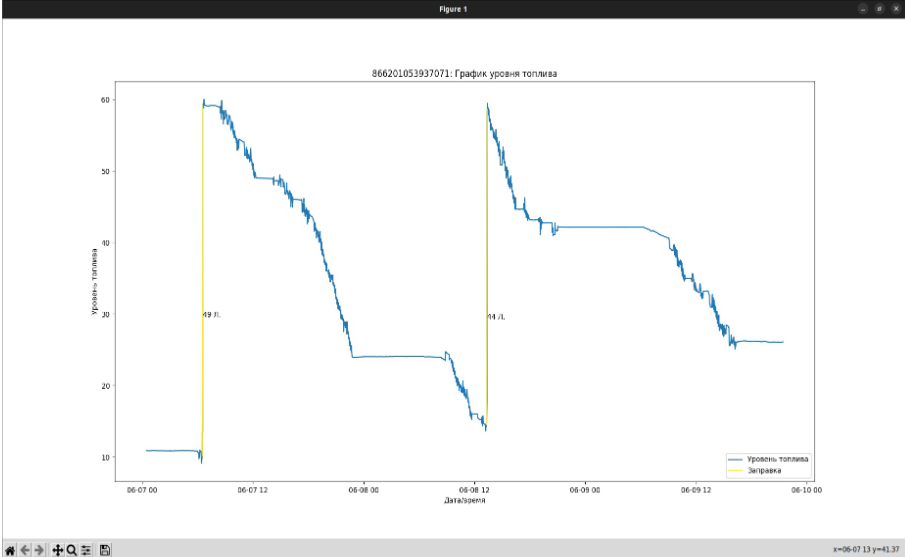

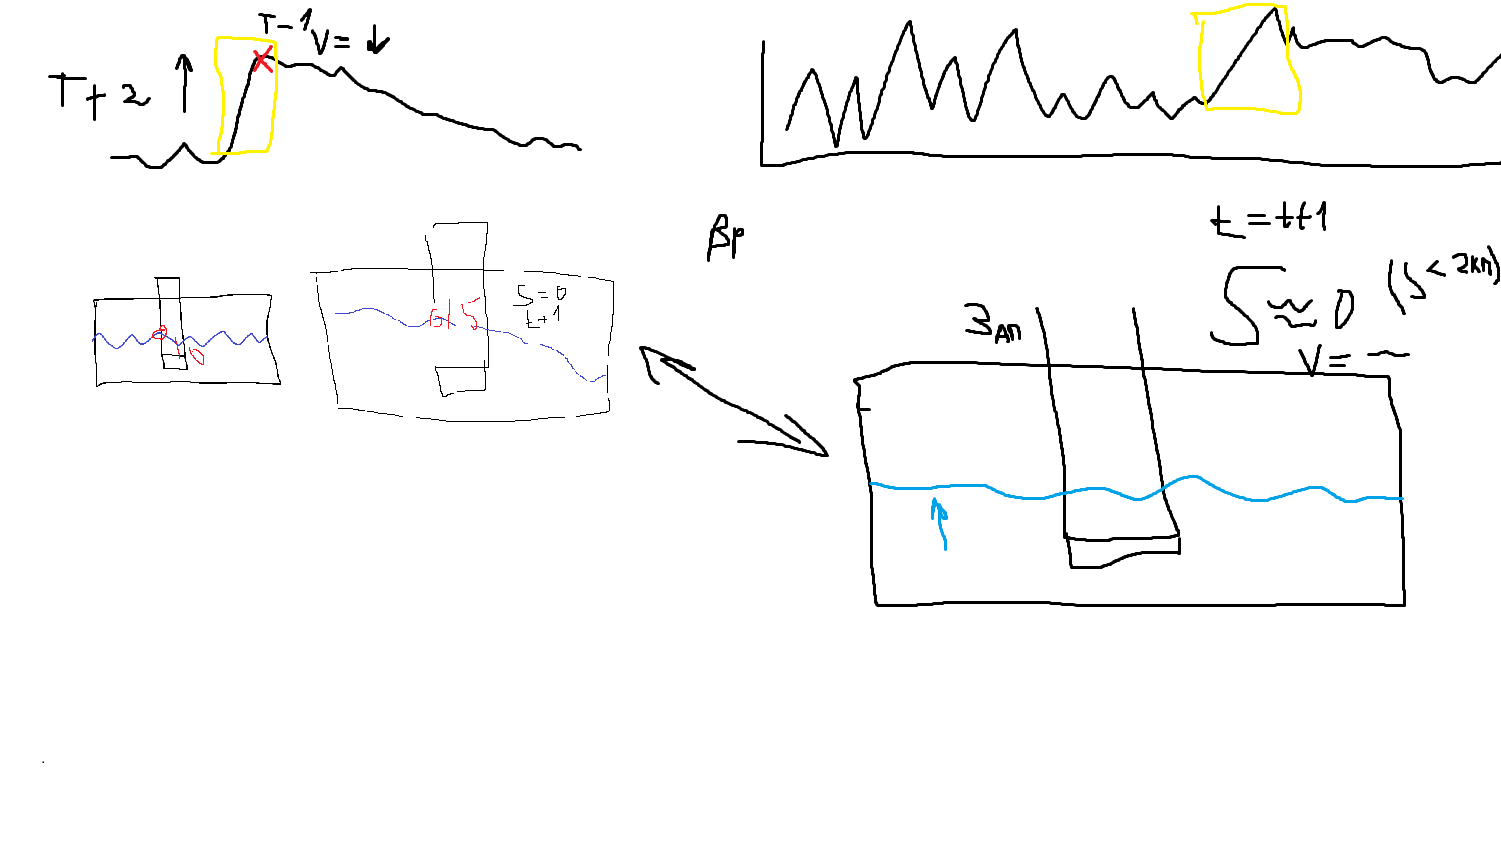

# Решение

## 1. Сделать 12 графиков скорости в зависимости от времени

In [4]:
df_zap.drop_duplicates(inplace=True)
df_zap.reset_index(drop=True, inplace=True)

In [5]:
# Для начала переведём timestamp в реальные временные данные
import datetime
df_zap['timestamp'] = pd.to_datetime(df_zap['timestamp'] * 1e9)

In [6]:
df_zap

,lat,lon,timestamp,speed,voltage,LLS
0,NaN,NaN,2023-12-31 21:00:13,NaN,25.20,1477.0
1,NaN,NaN,2023-12-31 21:03:56,NaN,25.20,1477.0
2,NaN,NaN,2023-12-31 21:04:21,NaN,25.20,1477.0
3,NaN,NaN,2023-12-31 21:05:51,NaN,25.20,1477.0
4,NaN,NaN,2023-12-31 21:05:27,NaN,25.20,1477.0
...,...,...,...,...,...,...
144099,56.070923,37.123569,2024-12-31 20:48:21,0.0,25.35,3345.0
144100,56.070923,37.123569,2024-12-31 20:50:51,0.0,25.35,3345.0
144101,56.070923,37.123569,2024-12-31 20:53:21,0.0,25.35,3345.0
144102,56.070923,37.123569,2024-12-31 20:55:51,0.0,25.35,3345.0


В датафрейме находятся данные за год с некоторой разницей во времени

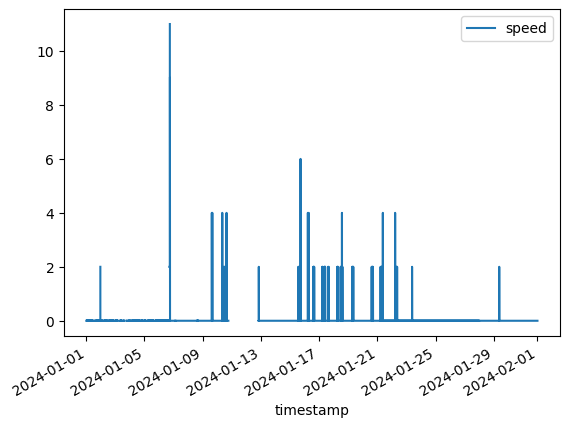

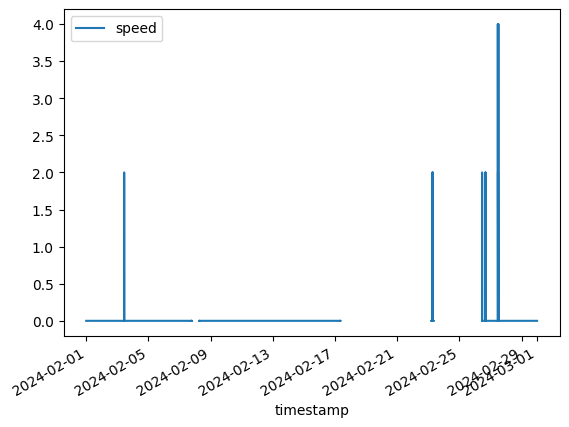

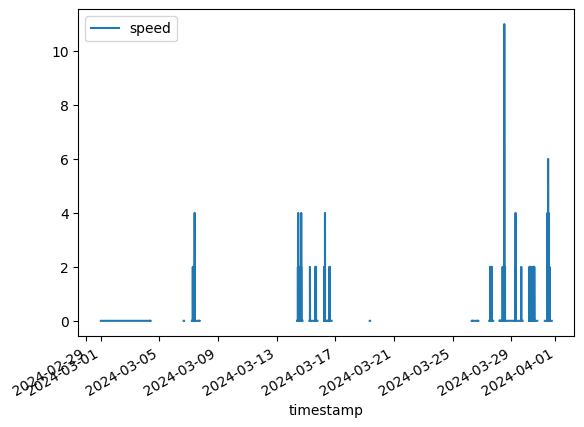

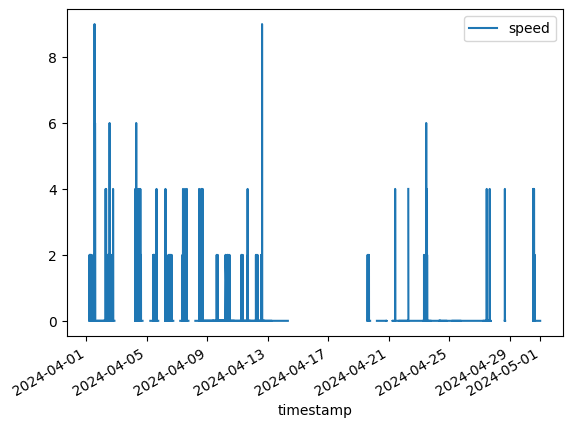

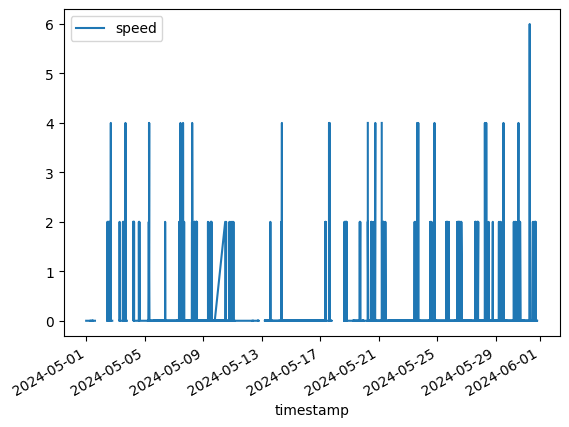

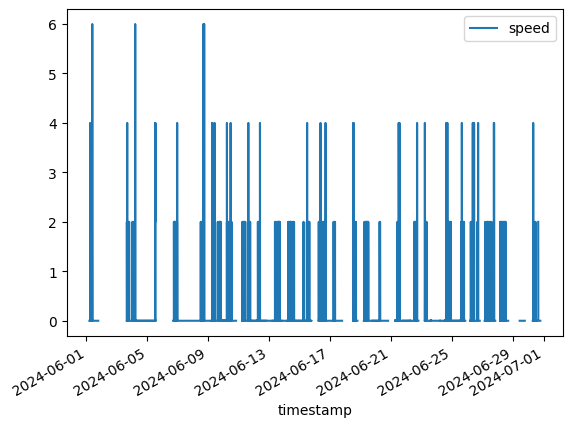

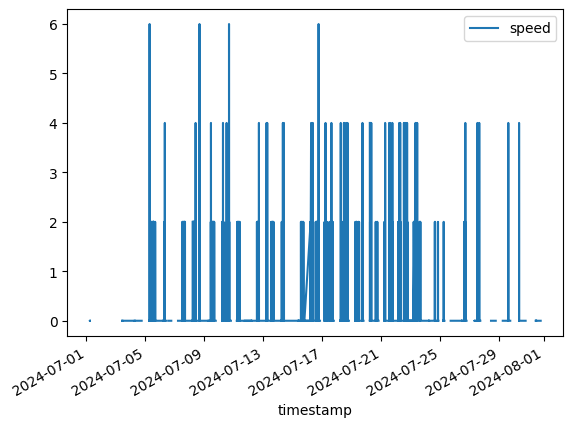

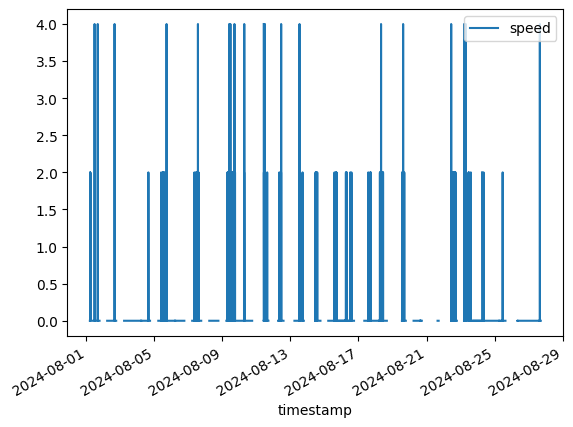

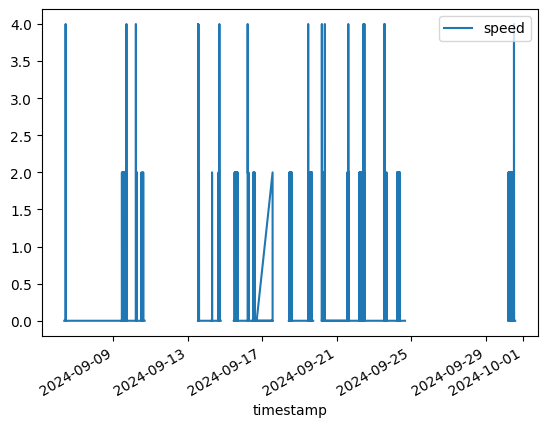

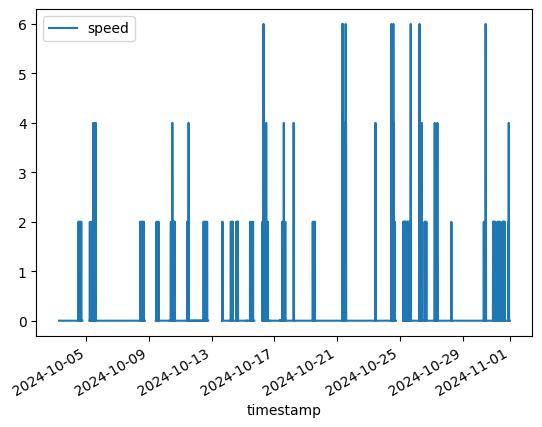

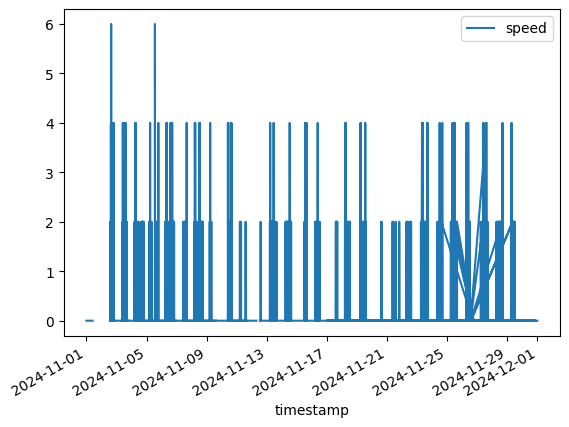

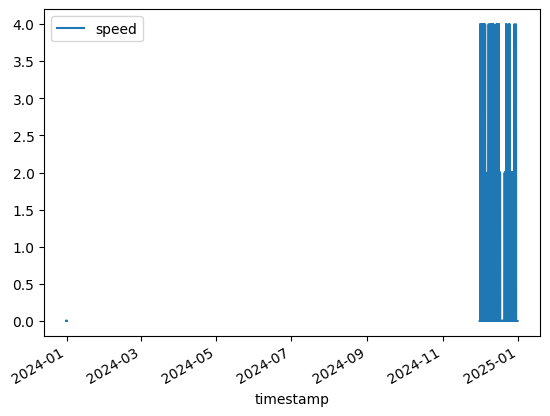

In [7]:
for i in range(1, 13):
    df_zap[df_zap['timestamp'].dt.month == i].plot(x='timestamp', y='speed')

Судя по всему эти данные не отсортированы по времени, либо в них есть сбои. Предполложим, что данные просто не отсортированы по времени.

In [8]:
df_zap = df_zap.sort_values(by='timestamp')

<Axes: xlabel='timestamp'>

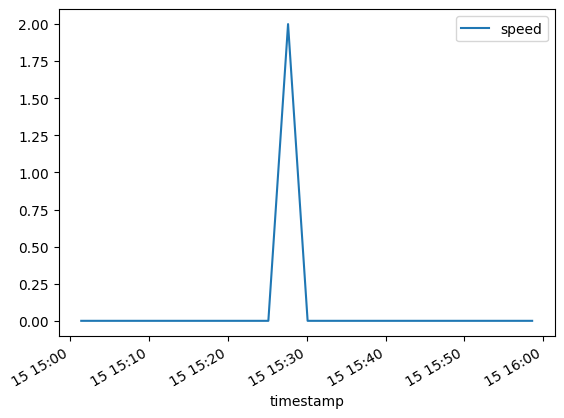

In [9]:
df_zap[(df_zap['timestamp'].dt.day_of_year == 15) & (df_zap['timestamp'].dt.hour == 15)].sort_values(by='timestamp').plot(x='timestamp', y='speed')

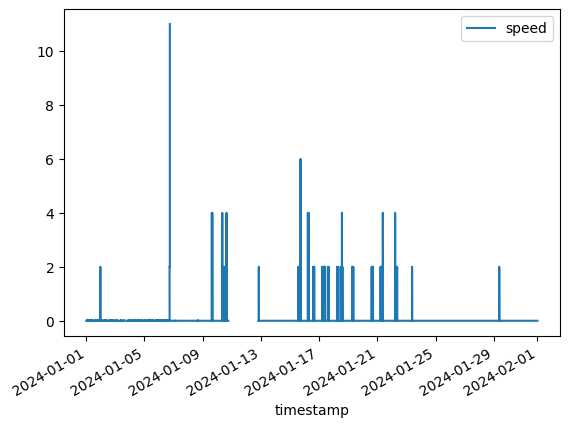

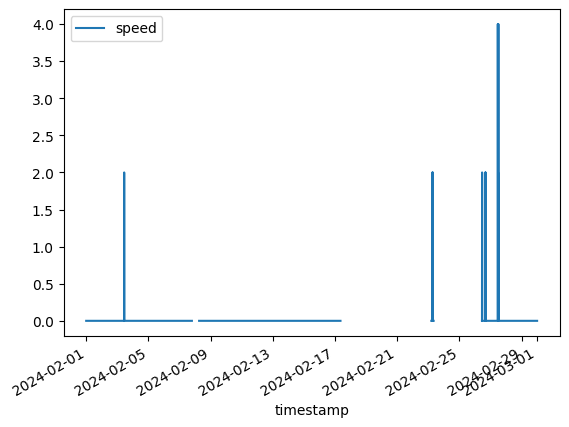

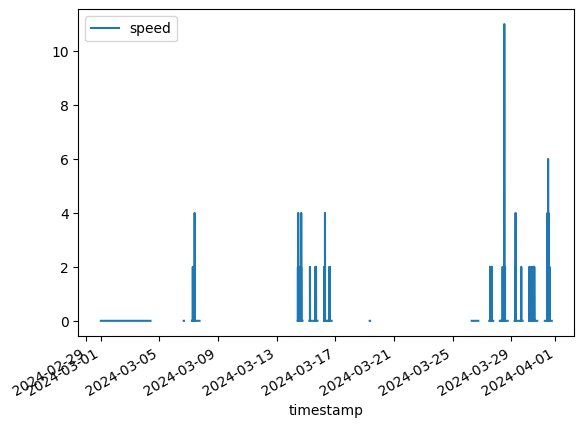

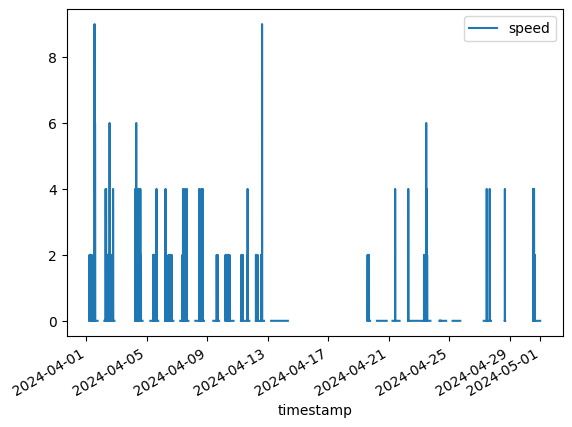

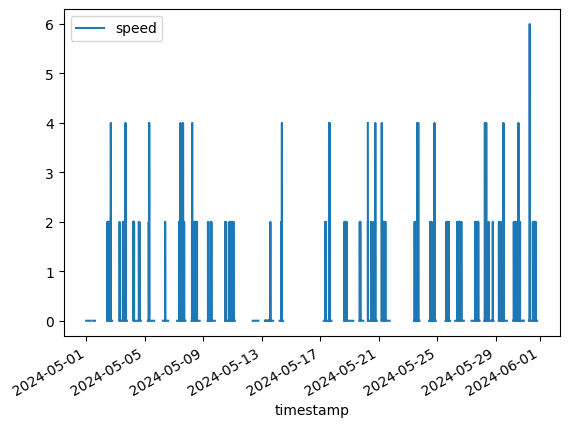

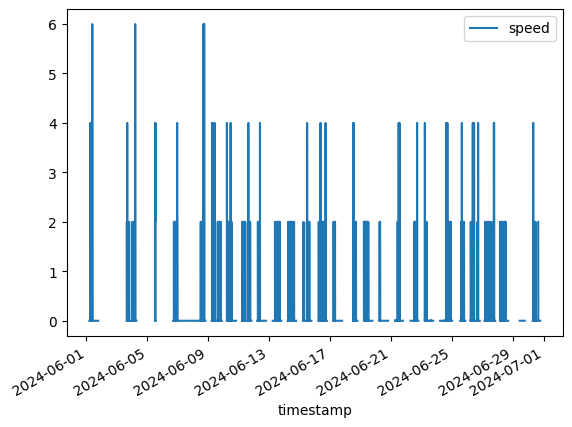

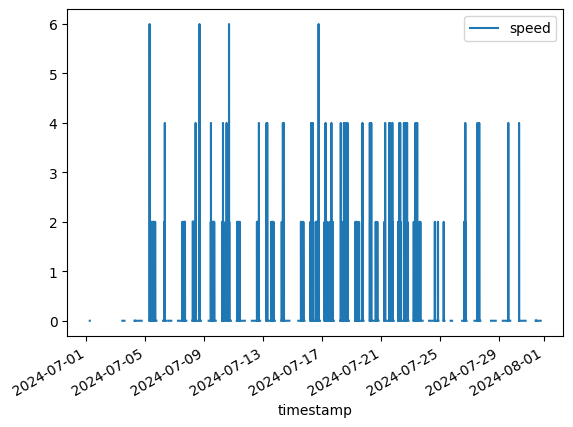

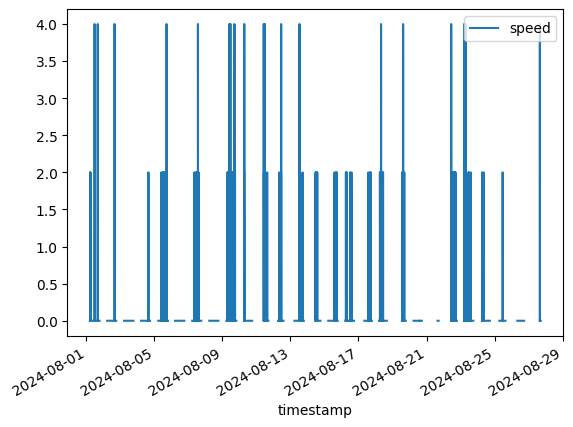

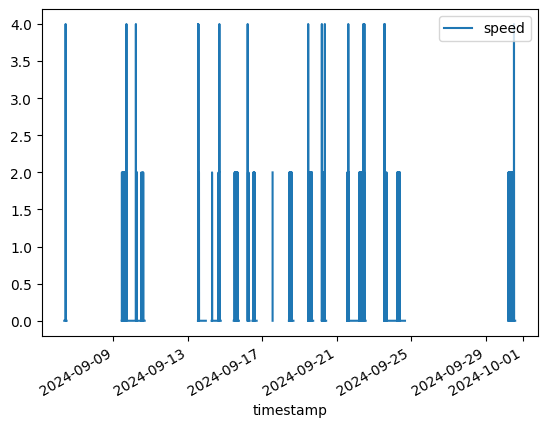

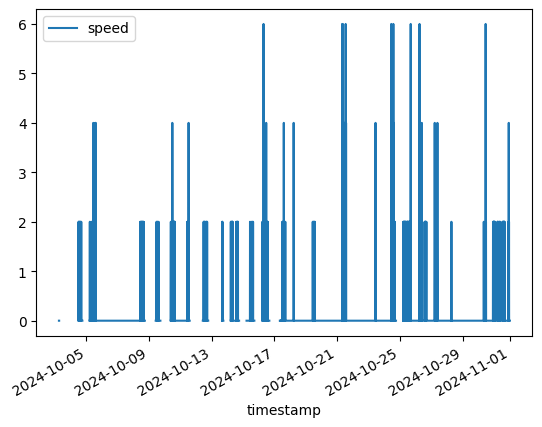

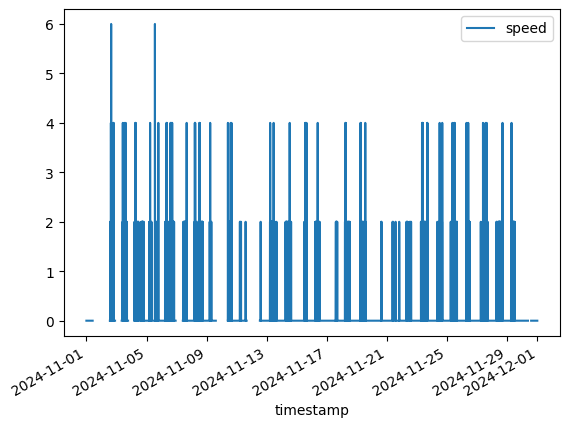

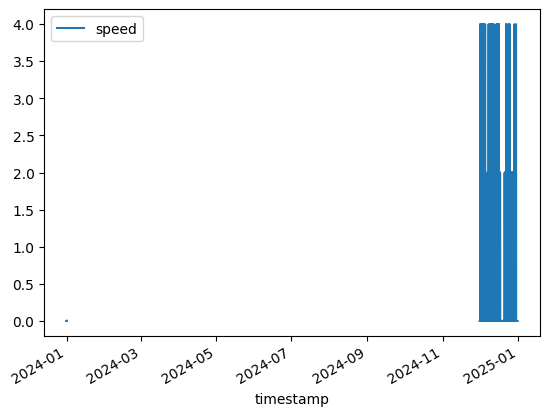

In [10]:
for i in range(1, 13):
    df_zap[df_zap['timestamp'].dt.month == i].plot(x='timestamp', y='speed')

Скорость похоже выражена не в километрах или милях в час, либо это особенность самого транспортного средства.

## 2. Создать алгоритм заправок

Построим графики уровняя топлива аналогично графикам скорости

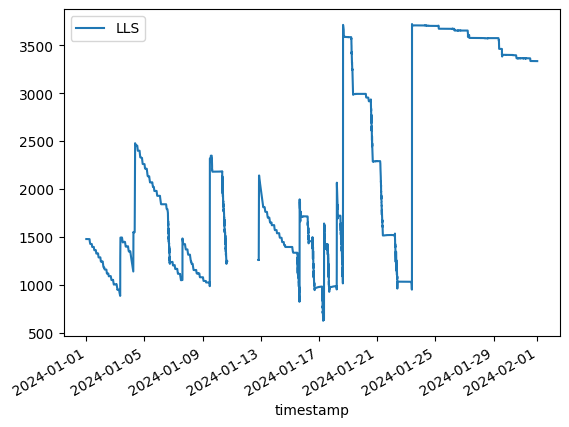

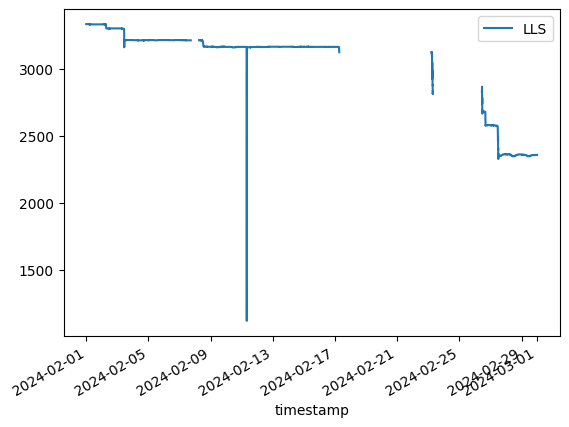

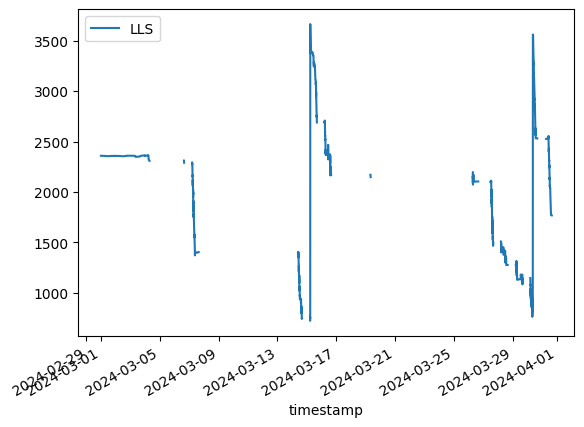

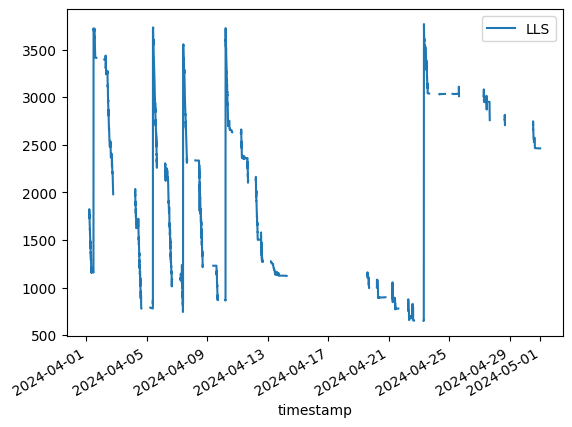

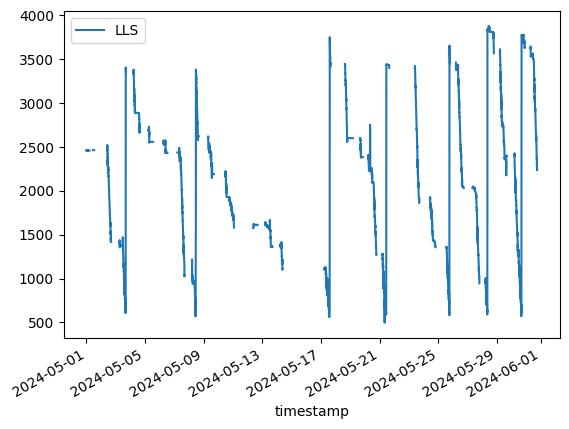

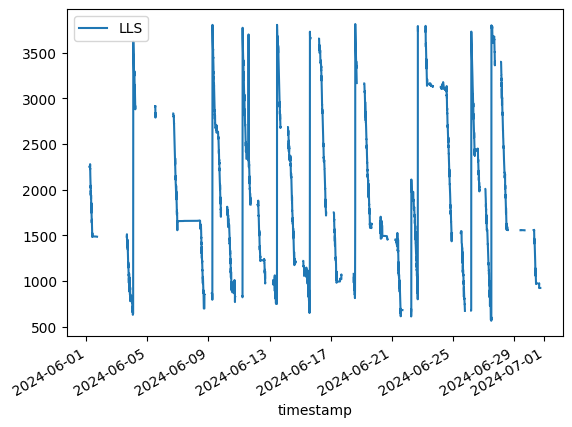

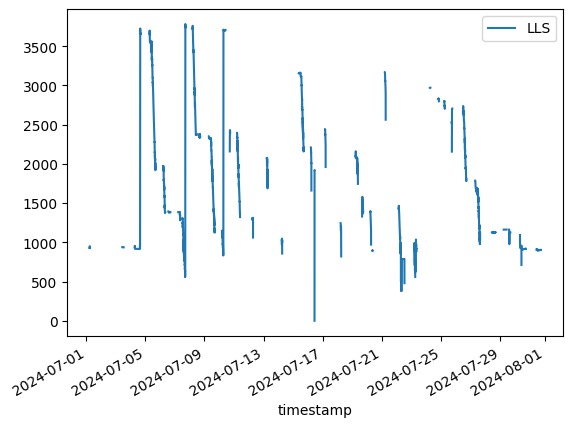

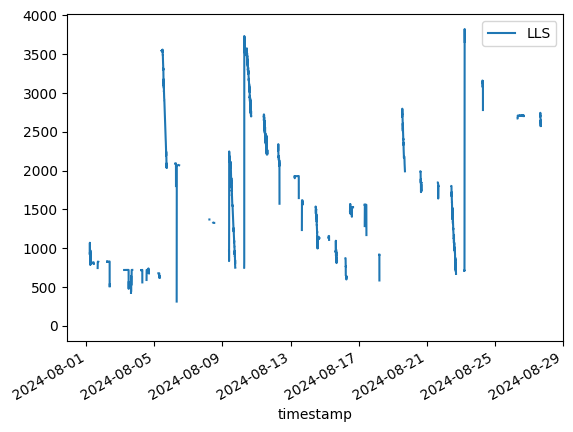

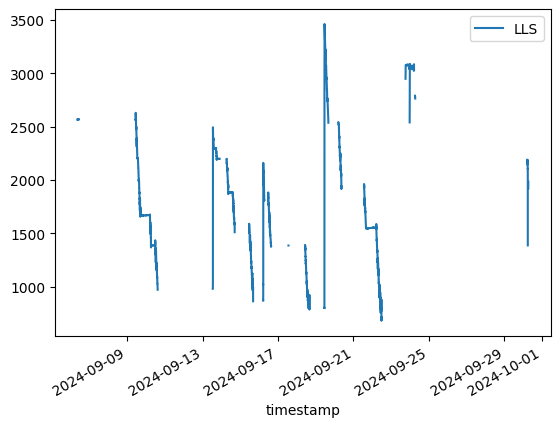

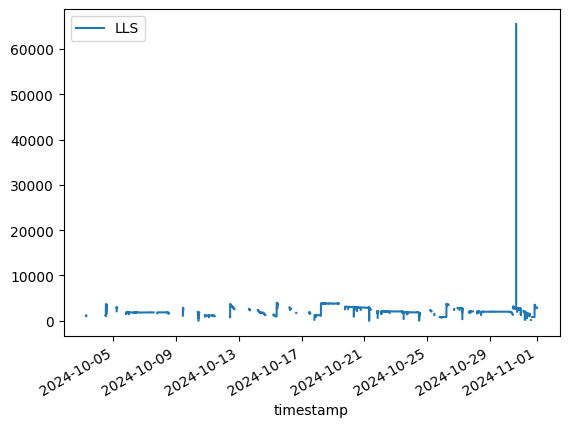

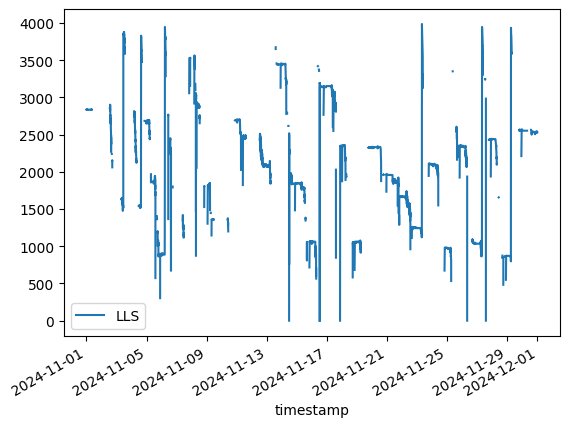

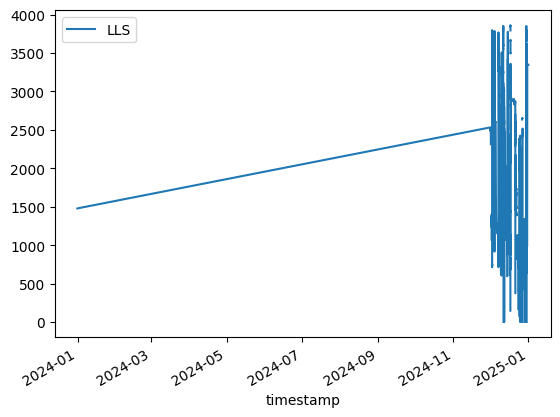

In [11]:
for i in range(1, 13):
    df_zap[df_zap['timestamp'].dt.month == i].plot(x='timestamp', y='LLS')

In [12]:
import matplotlib.pyplot as plt

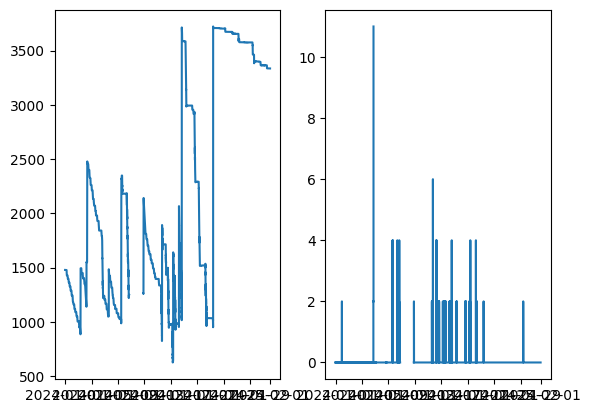

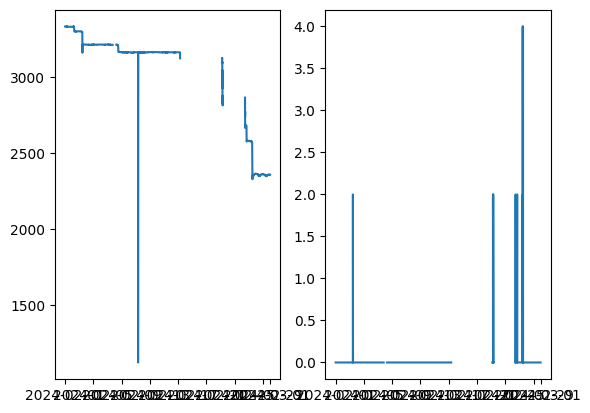

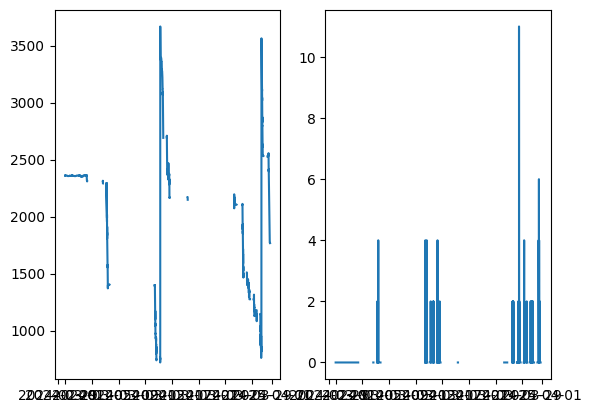

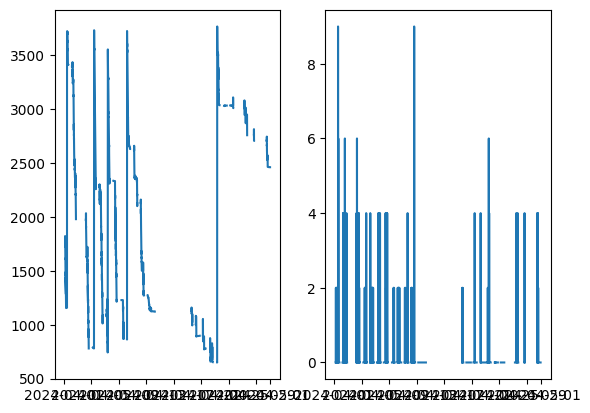

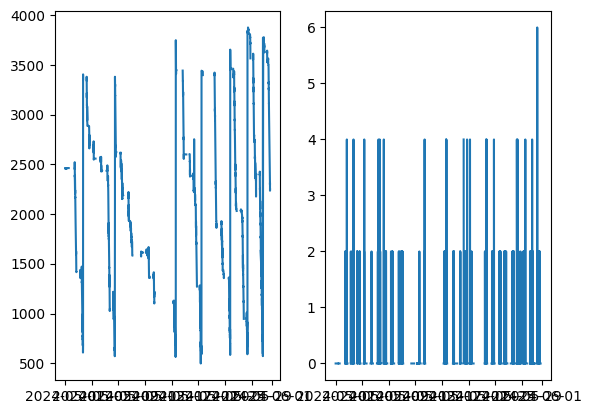

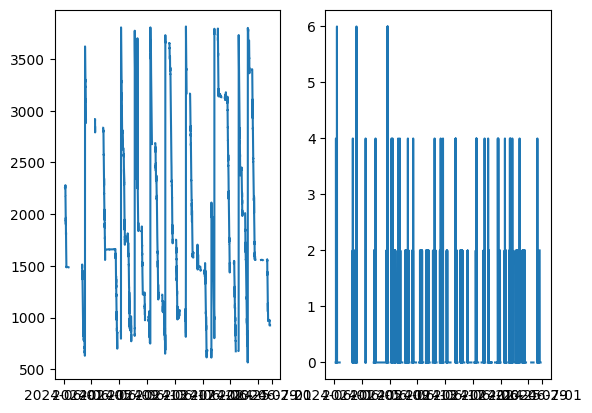

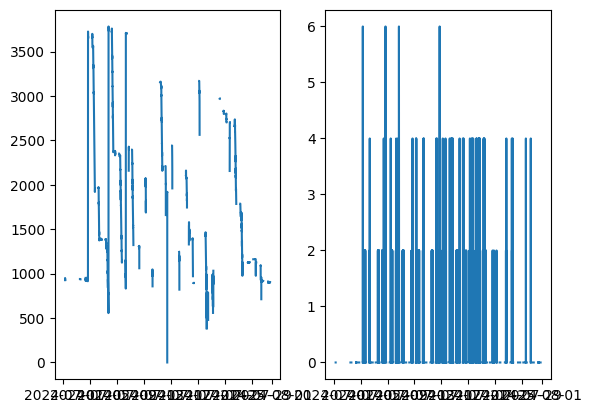

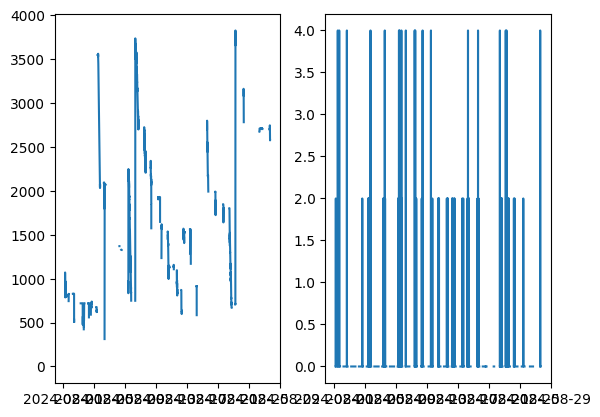

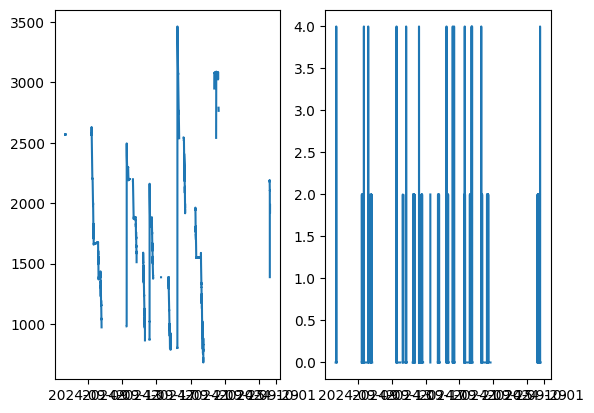

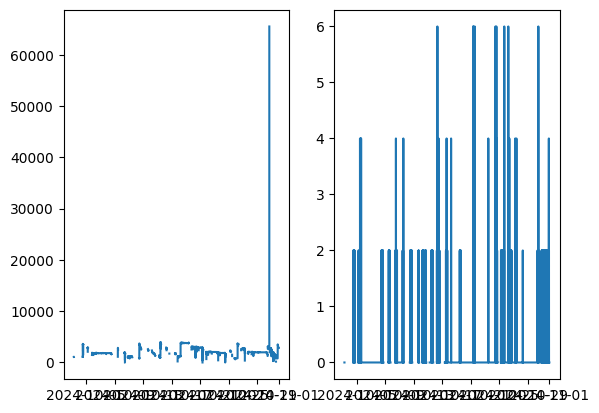

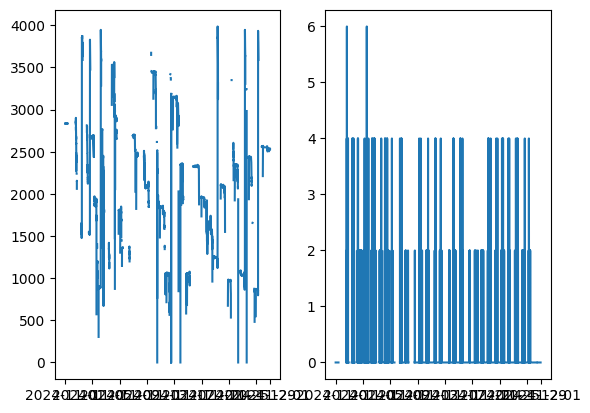

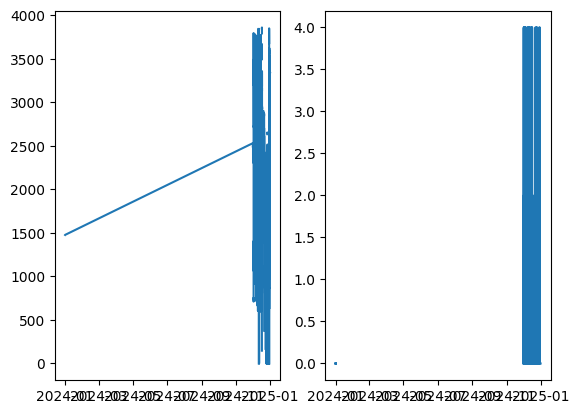

In [13]:
for i in range(1, 13):
    df_to_plot = df_zap[df_zap['timestamp'].dt.month == i]
    figure, axis = plt.subplots(1, 2)
    axis[0].plot(df_to_plot['timestamp'], df_to_plot['LLS'])
    axis[1].plot(df_to_plot['timestamp'], df_to_plot['speed'])

In [14]:
import datetime as dt

<Axes: xlabel='timestamp'>

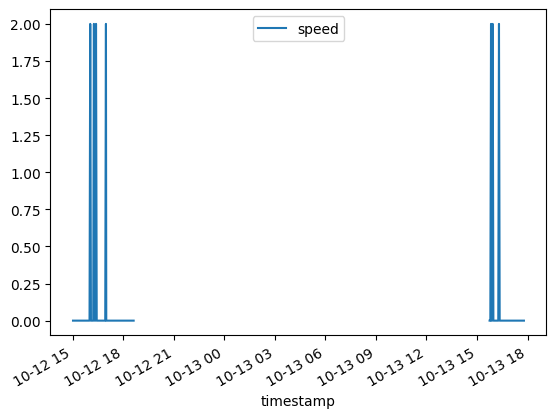

In [15]:
df_zap[(df_zap['timestamp'] <= dt.datetime(2024, 10, 13, 19)) & (df_zap['timestamp'] >= dt.datetime(2024, 10, 12, 15))].plot(x='timestamp', y='speed')

Введём столбец `fill_or_steal`, в который в дальнейшем будем записывать следующие значения:
- `1` - Заправка;
- `0` - Машина едет/стоит (никаких необычных ситуаций с топливом);
- `-1` - Топливо сливают.

In [16]:
df_zap['fill_or_steal'] = 0

Определим в каких местах топливо повышается

In [17]:
df_zap['fuel_surplus'] = False

In [18]:
for i in range(1, df_zap.shape[0]):
    if df_zap.loc[i, 'LLS'] > df_zap.loc[i - 1, 'LLS']:
        df_zap.loc[i, 'fuel_surplus'] = True

Теперь отрисуем эти графики с повышением топлива:

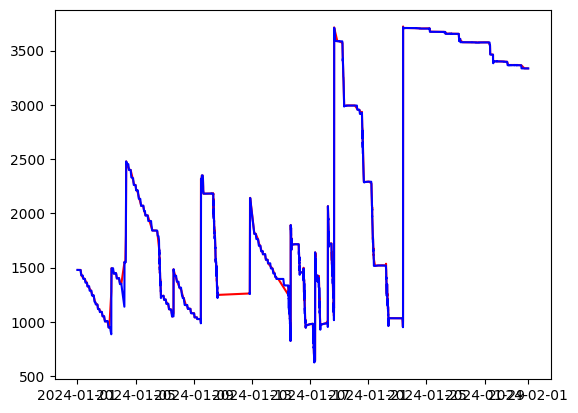

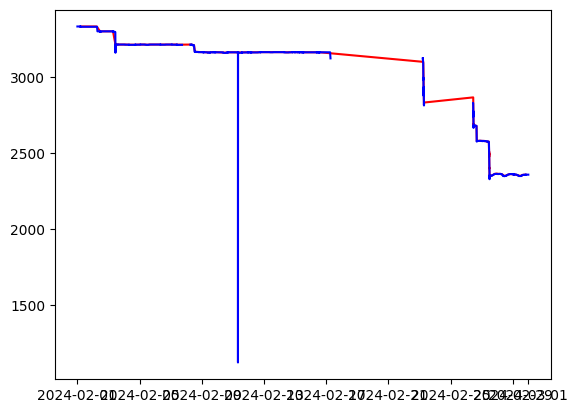

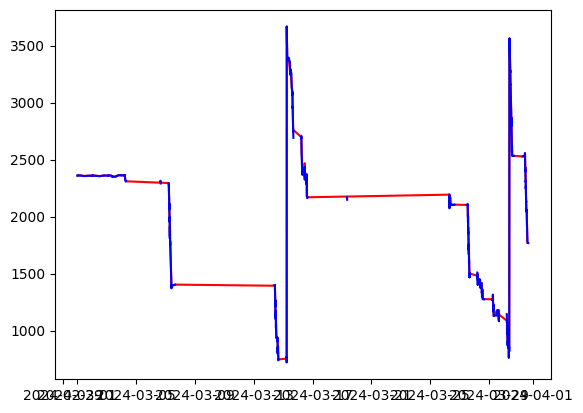

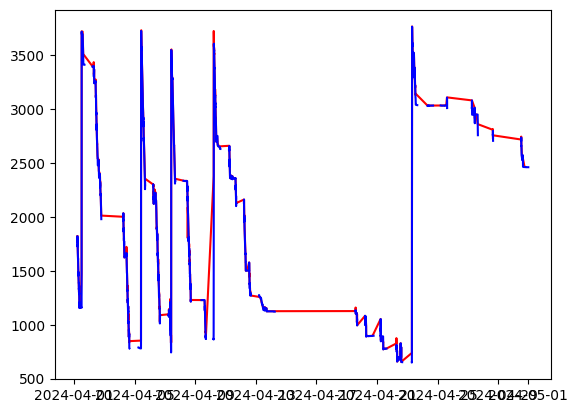

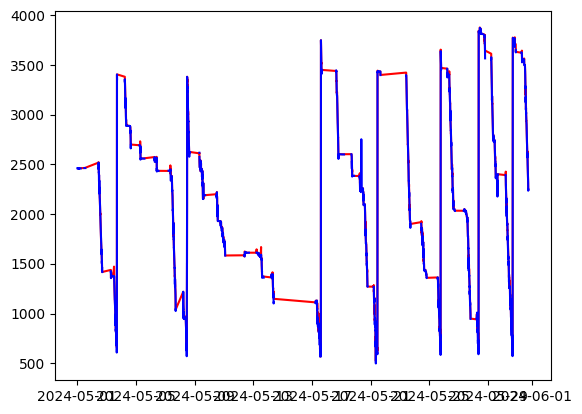

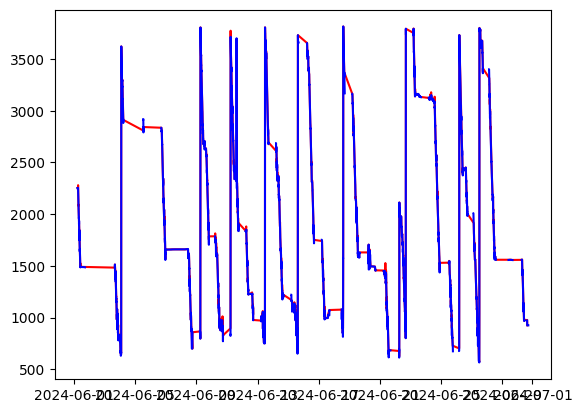

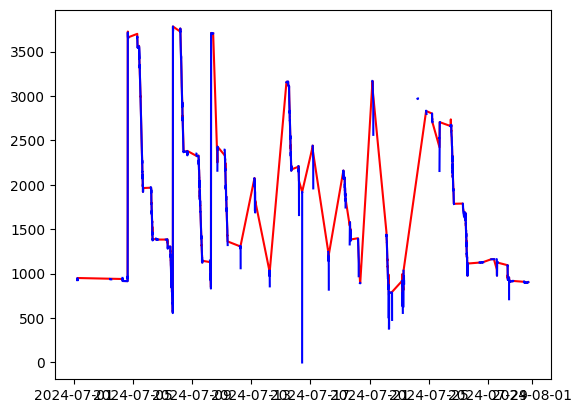

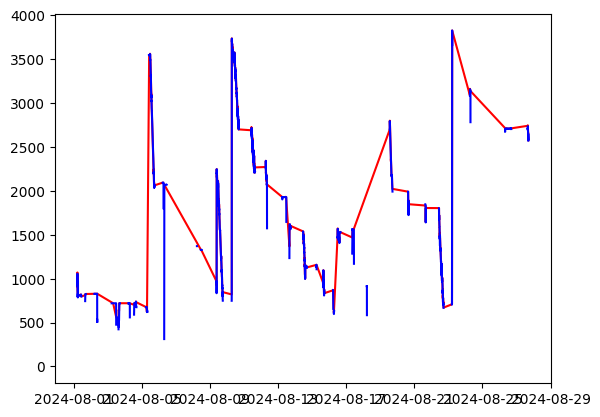

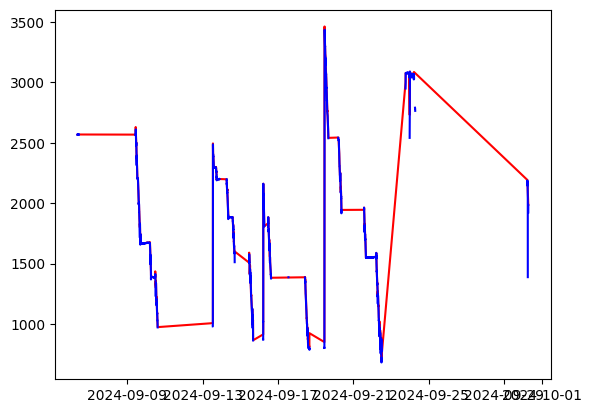

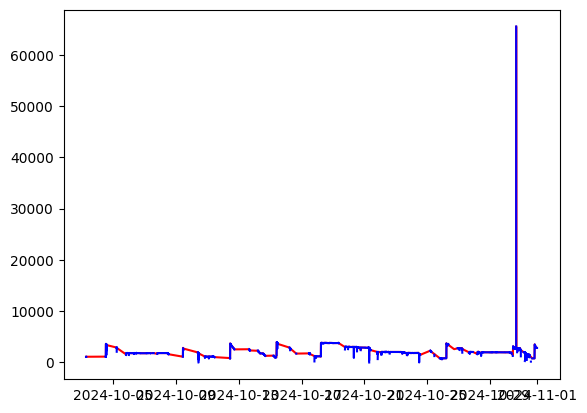

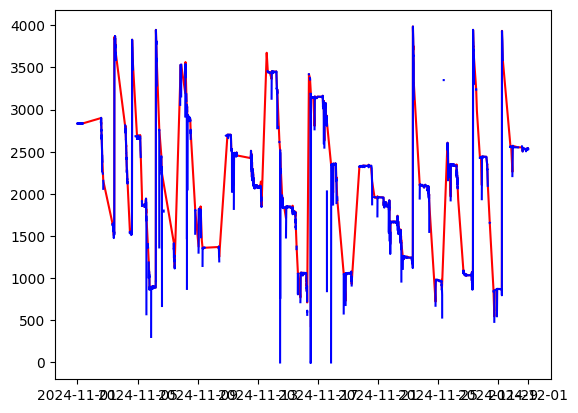

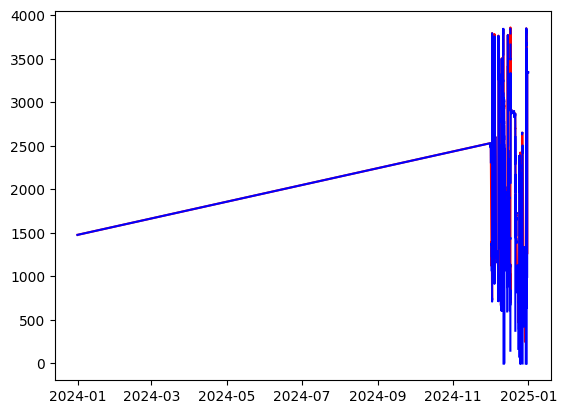

In [19]:
for i in range(1, 13):
    df_to_plot = df_zap[(df_zap['timestamp'].dt.month == i) & (df_zap['fuel_surplus'] == True)]
    plt.plot(df_to_plot['timestamp'], df_to_plot['LLS'], color='red')
    df_to_plot = df_zap[(df_zap['timestamp'].dt.month == i) & (df_zap['fuel_surplus'] == False)]
    plt.plot(df_to_plot['timestamp'], df_to_plot['LLS'], color='blue')
    plt.show()

Посчитаем по координатам перемещение ТС

In [20]:
import numpy as np

In [21]:
r = 6400000

def dist(lat2, lat1, long2, long1):
    dist_r = abs(lat1 - lat2) * 111160
    dist_z = abs(long1 - long2) * np.cos(min(abs(long1), abs(long2)) * np.pi / 180) * 111300
    dist_f = ((dist_r / r) ** 2 + (dist_z / r) ** 2) ** 0.5 * r
    return dist_f

In [22]:
df_zap['distant'] = 0.0
for j in range(1, df_zap.shape[0]):
        df_zap.loc[j, 'distant'] = dist(df_zap.loc[j, 'lat'], df_zap.loc[j - 1, 'lat'], df_zap.loc[j, 'lon'], df_zap.loc[j - 1, 'lon'])

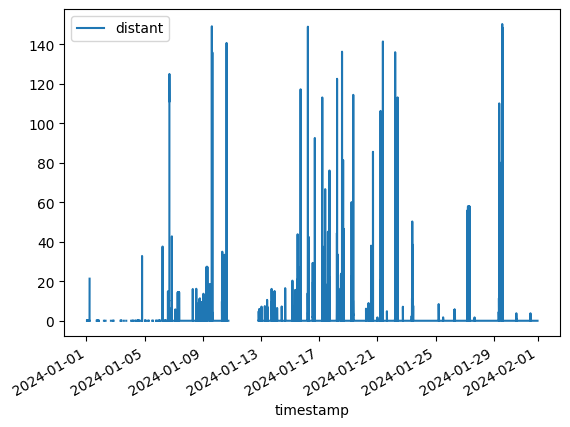

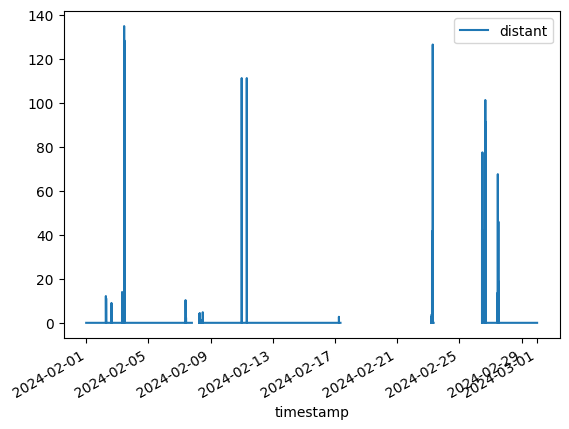

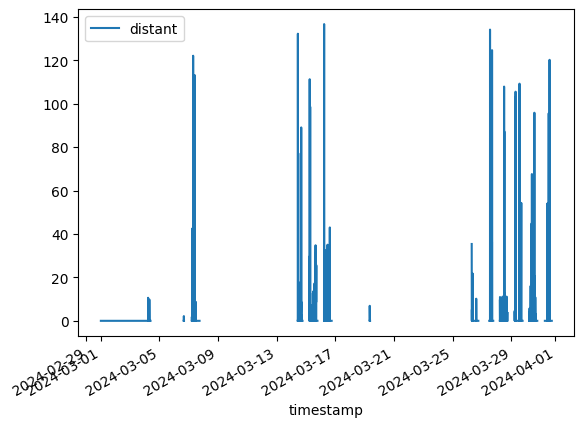

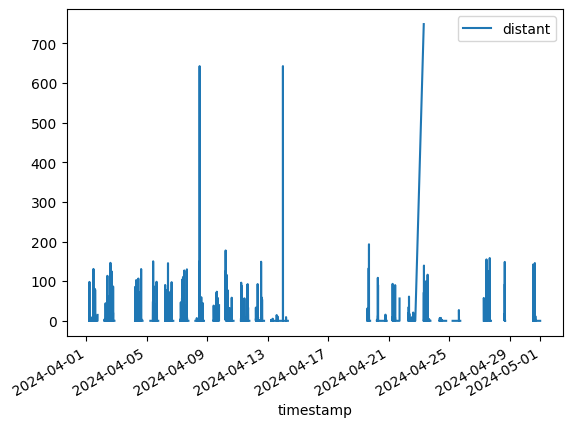

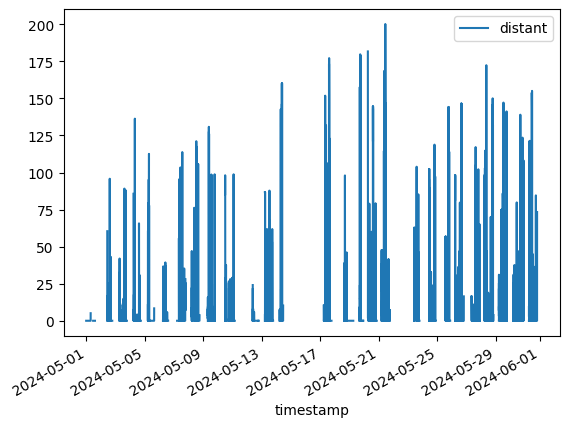

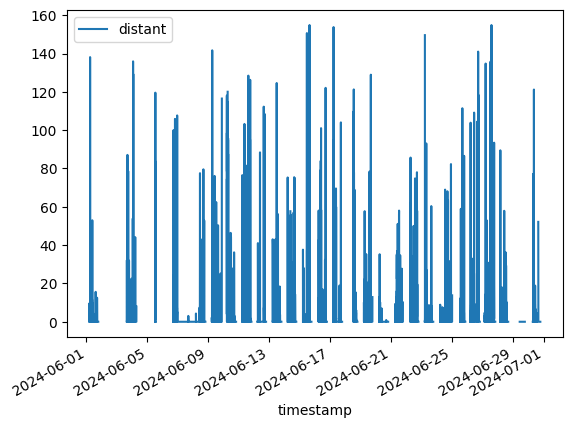

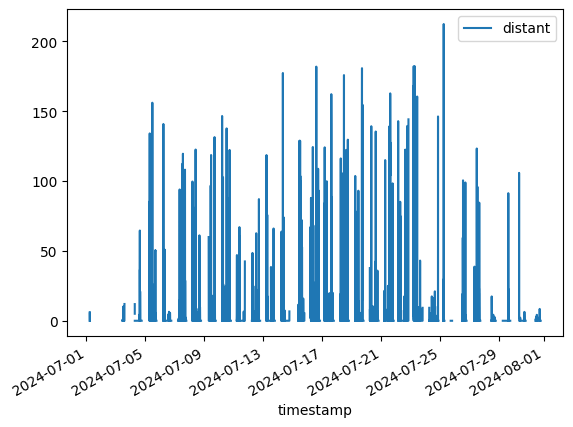

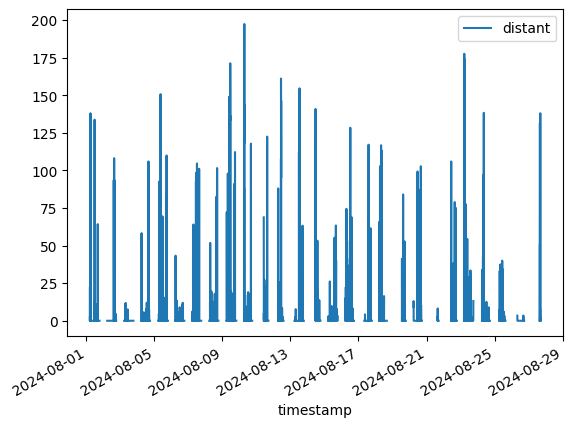

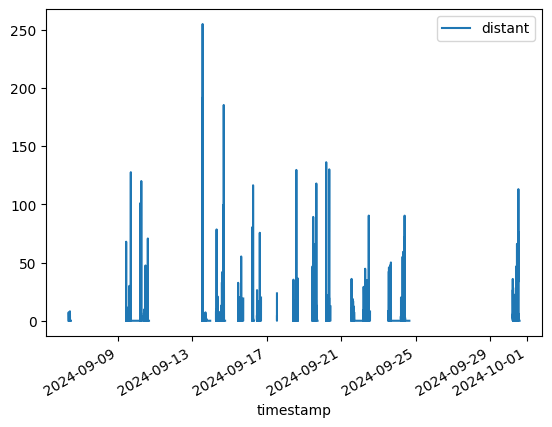

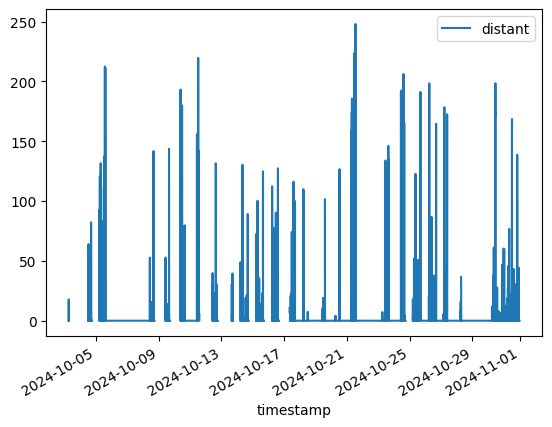

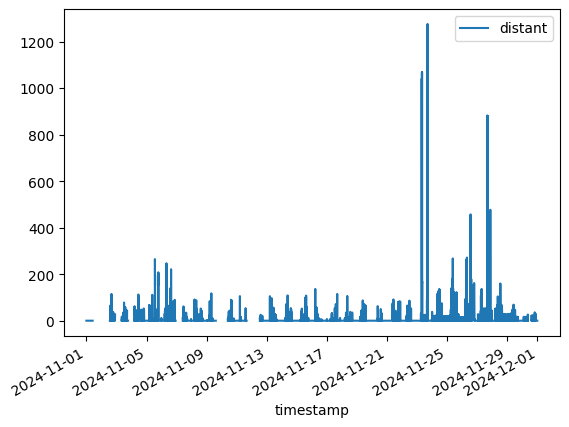

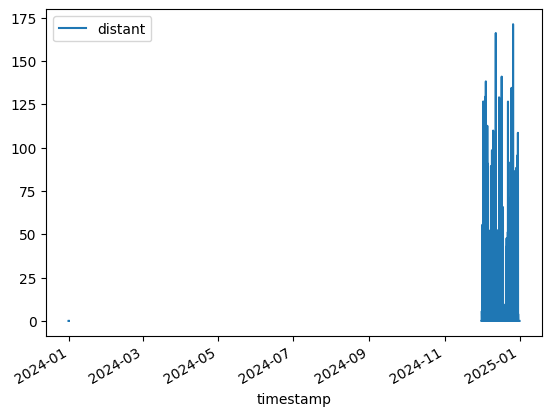

In [23]:
for i in range(1, 13):
    df_zap[df_zap['timestamp'].dt.month == i].plot(x='timestamp', y='distant')

Высчитаем таким образом скорость автомобиля

In [24]:
df_zap

,lat,lon,timestamp,speed,voltage,LLS,fill_or_steal,fuel_surplus,distant
0,NaN,NaN,2023-12-31 21:00:13,NaN,25.20,1477.0,0,False,0.0
1,NaN,NaN,2023-12-31 21:03:56,NaN,25.20,1477.0,0,False,NaN
2,NaN,NaN,2023-12-31 21:04:21,NaN,25.20,1477.0,0,False,NaN
5,NaN,NaN,2023-12-31 21:04:55,NaN,25.20,1477.0,0,False,NaN
4,NaN,NaN,2023-12-31 21:05:27,NaN,25.20,1477.0,0,False,NaN
...,...,...,...,...,...,...,...,...,...
144099,56.070923,37.123569,2024-12-31 20:48:21,0.0,25.35,3345.0,0,False,0.0
144100,56.070923,37.123569,2024-12-31 20:50:51,0.0,25.35,3345.0,0,False,0.0
144101,56.070923,37.123569,2024-12-31 20:53:21,0.0,25.35,3345.0,0,False,0.0
144102,56.070923,37.123569,2024-12-31 20:55:51,0.0,25.35,3345.0,0,False,0.0


In [25]:
df_zap['speed_calc'] = 0.0
df_zap['seconds'] = 0.0
for j in range(1, df_zap.shape[0]):
    df_zap.loc[j, 'seconds'] = (df_zap.loc[j, 'timestamp'] - df_zap.loc[j - 1, 'timestamp']).seconds
df_zap['speed_calc'] = df_zap['distant'] / 1000.0 / (df_zap['seconds'] / 3600.0)

In [26]:
df_zap.describe()

,lat,lon,timestamp,speed,voltage,LLS,fill_or_steal,distant,speed_calc,seconds
count,141516.000000,141516.000000,144104,141516.000000,143879.000000,105075.000000,144104.0,140529.000000,140394.000000,144104.000000
mean,56.071288,37.118724,2024-07-18 23:03:54.868810240,0.049486,24.537589,2180.576236,0.0,2.664292,0.077385,5875.156047
min,56.057796,37.105957,2023-12-31 21:00:13,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,56.070995,37.116390,2024-04-06 07:01:35.500000,0.000000,25.350000,1412.000000,0.0,0.000000,0.000000,149.000000
50%,56.071304,37.116592,2024-07-24 08:18:46,0.000000,25.800000,2112.000000,0.0,0.000000,0.000000,150.000000
75%,56.071510,37.123062,2024-11-08 02:10:03.500000,0.000000,27.300000,2994.000000,0.0,0.000000,0.000000,150.000000
max,56.076244,37.131790,2024-12-31 20:58:20,11.000000,35.700000,65535.000000,0.0,1275.825227,248.274751,86399.000000
std,0.000511,0.003524,NaN,0.350150,6.412380,1109.150300,0.0,15.994075,0.917103,21188.317290


In [27]:
df_zap['fuel_diff'] = 0.0
for i in range(1, df_zap.shape[0]):
    df_zap.loc[i, 'fuel_diff'] = df_zap.loc[i, 'LLS'] - df_zap.loc[i - 1, 'LLS']

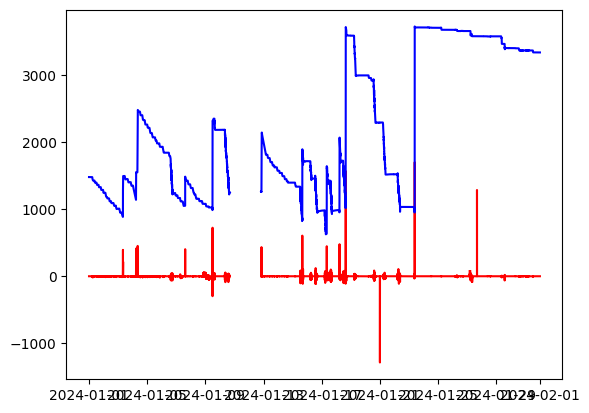

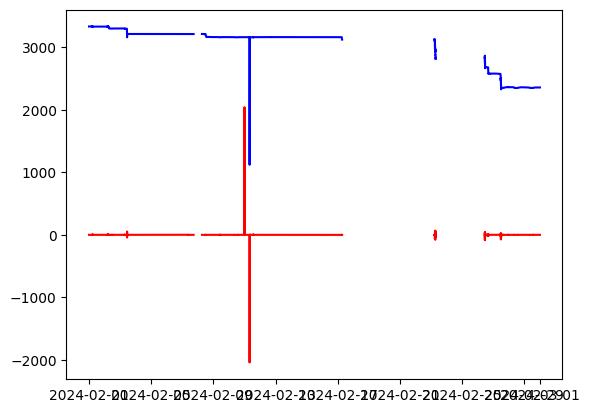

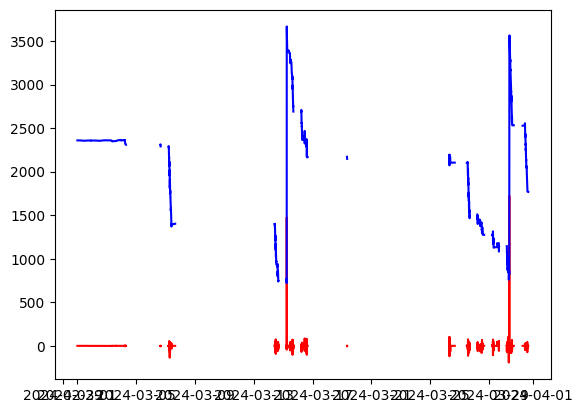

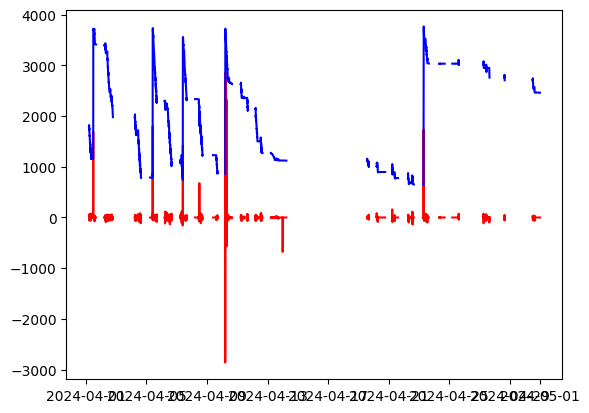

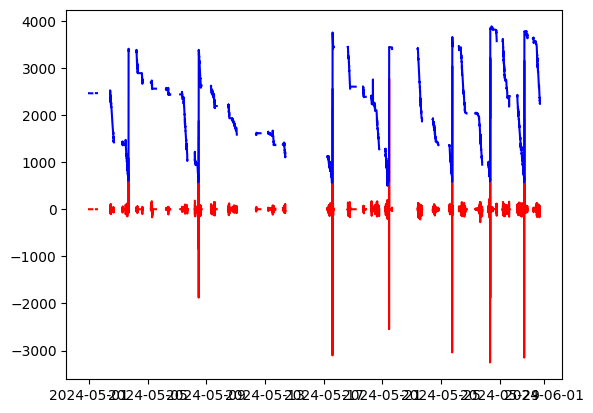

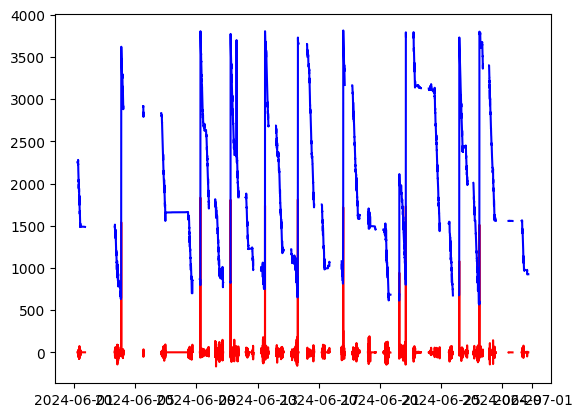

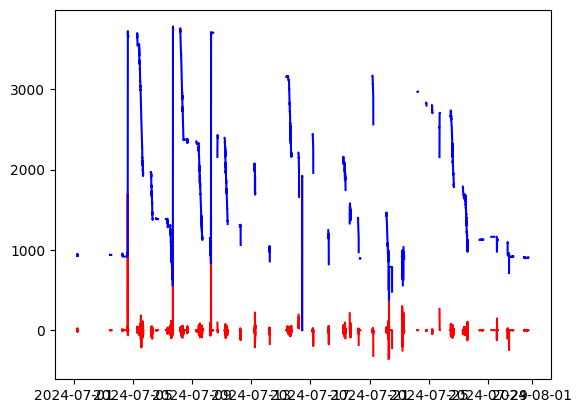

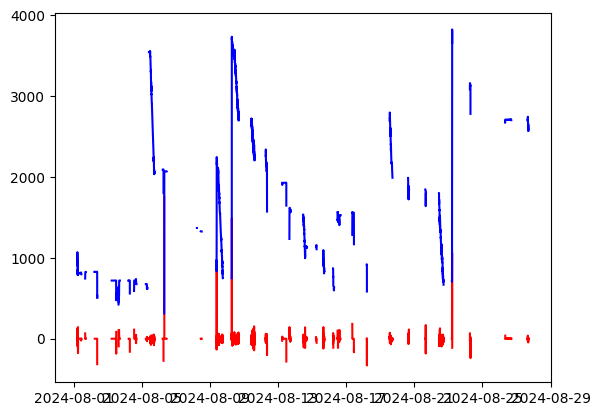

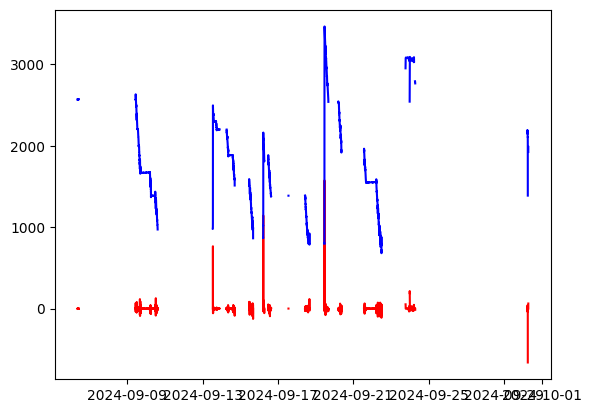

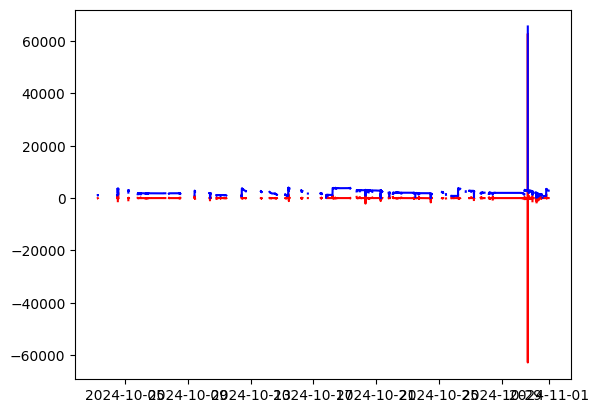

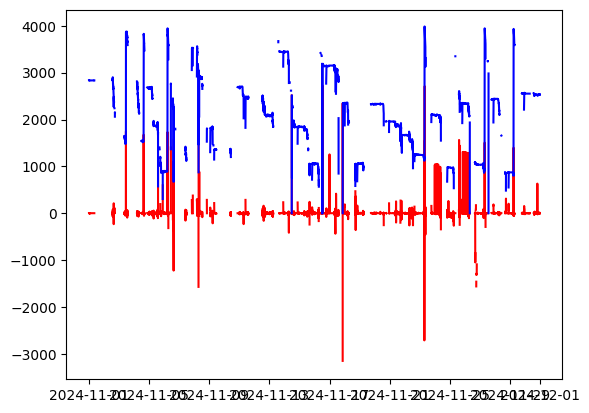

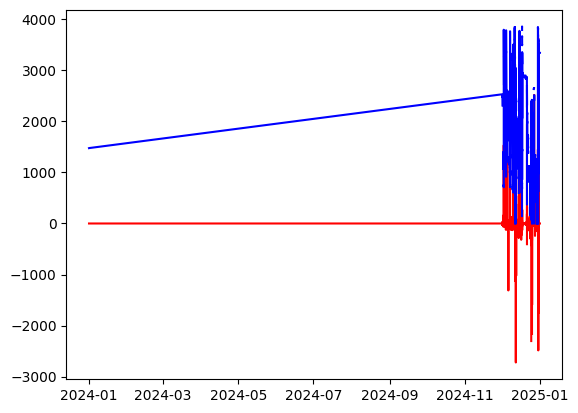

In [28]:
for i in range(1, 13):
    df_to_plot = df_zap[df_zap['timestamp'].dt.month == i]
    plt.plot(df_to_plot['timestamp'], df_to_plot['fuel_diff'], color='red')
    plt.plot(df_to_plot['timestamp'], df_to_plot['LLS'], color='blue')
    plt.show()

Предположим, что во время заправки для ТС характерно следующее:
1. Скорость околонулевая (меньше 5 км/ч допустим);
2. Координаты практически не меняются (возможны небольшие изменения, допустим в пределах 10 метров за счёт корректности работы датчиков GPS)
3. Топливо растёт в течение некоторого промежутка времени (допустим от 3 минут и не более 15 минут, иначе это скорее всего какое-то другое событие)
4. Альтернативно третьему пункту можно предложить, что по итогам промежутка простоя количество топлива увеличилось.

In [29]:
df_zap.describe()

,lat,lon,timestamp,speed,voltage,LLS,fill_or_steal,distant,speed_calc,seconds,fuel_diff
count,141516.000000,141516.000000,144104,141516.000000,143879.000000,105075.000000,144104.0,140529.000000,140394.000000,144104.000000,103867.000000
mean,56.071288,37.118724,2024-07-18 23:03:54.868810240,0.049486,24.537589,2180.576236,0.0,2.664292,0.077385,5875.156047,1.269855
min,56.057796,37.105957,2023-12-31 21:00:13,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,-62781.000000
25%,56.070995,37.116390,2024-04-06 07:01:35.500000,0.000000,25.350000,1412.000000,0.0,0.000000,0.000000,149.000000,0.000000
50%,56.071304,37.116592,2024-07-24 08:18:46,0.000000,25.800000,2112.000000,0.0,0.000000,0.000000,150.000000,0.000000
75%,56.071510,37.123062,2024-11-08 02:10:03.500000,0.000000,27.300000,2994.000000,0.0,0.000000,0.000000,150.000000,0.000000
max,56.076244,37.131790,2024-12-31 20:58:20,11.000000,35.700000,65535.000000,0.0,1275.825227,248.274751,86399.000000,62781.000000
std,0.000511,0.003524,NaN,0.350150,6.412380,1109.150300,0.0,15.994075,0.917103,21188.317290,350.721117


In [30]:
df_zap2 = df_zap.copy()

In [31]:
df_zap = df_zap2.head(2000)

In [32]:
df_zap.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   lat            678 non-null    float64       
 1   lon            678 non-null    float64       
 2   timestamp      2000 non-null   datetime64[ns]
 3   speed          678 non-null    float64       
 4   voltage        2000 non-null   float64       
 5   LLS            2000 non-null   float64       
 6   fill_or_steal  2000 non-null   int64         
 7   fuel_surplus   2000 non-null   bool          
 8   distant        252 non-null    float64       
 9   speed_calc     249 non-null    float64       
 10  seconds        2000 non-null   float64       
 11  fuel_diff      2000 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(9), int64(1)
memory usage: 189.5 KB


In [33]:
df_zap = df_zap.sort_values(by='timestamp').reset_index(drop=True)

In [34]:
df_zap['less_than_10'] = True
df_zap['no_movement'] = True
i = 0
while i < df_zap.shape[0] - 1:
    if df_zap.loc[i, 'distant'] > 10.0:
        df_zap.loc[i, 'less_than_10'] = False
    if df_zap.loc[i, 'speed_calc'] > 5.0:
        df_zap.loc[i, 'no_movement'] = False
    if df_zap.loc[i, 'less_than_10'] == True and df_zap.loc[i, 'no_movement'] == True:
        fuel_df = df_zap[((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) < dt.timedelta(seconds=900)) & ((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) >= dt.timedelta(seconds=0))].copy()
        fuel_surpl = fuel_df.loc[fuel_df.index[1:], 'LLS'].max() - df_zap.loc[i, 'LLS']
        if fuel_surpl > 50 and fuel_df.loc[fuel_df.index[-1], 'LLS'] > df_zap.loc[i, 'LLS']:
            fin = fuel_df.index[-1]
            print(df_zap[((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) < dt.timedelta(seconds=900)) & ((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) >= dt.timedelta(seconds=0))].index)
            for j in df_zap[((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) < dt.timedelta(seconds=900)) & ((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) >= dt.timedelta(seconds=0))].index:
                df_zap.loc[j, 'fill_or_steal'] = 1
            i = j
    i += 1

Index([1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231], dtype='int64')
Index([1233, 1234, 1235], dtype='int64')
Index([1572, 1573, 1574, 1575], dtype='int64')
Index([1613, 1614, 1615, 1616], dtype='int64')
Index([1617, 1618], dtype='int64')
Index([1619, 1620, 1621, 1622], dtype='int64')


In [35]:
df_zap

,lat,lon,timestamp,speed,voltage,LLS,fill_or_steal,fuel_surplus,distant,speed_calc,seconds,fuel_diff,less_than_10,no_movement
0,NaN,NaN,2023-12-31 21:00:13,NaN,25.20,1477.0,0,False,0.0,NaN,0.0,0.0,True,True
1,NaN,NaN,2023-12-31 21:03:56,NaN,25.20,1477.0,0,False,NaN,NaN,223.0,0.0,True,True
2,NaN,NaN,2023-12-31 21:04:21,NaN,25.20,1477.0,0,False,NaN,NaN,25.0,0.0,True,True
3,NaN,NaN,2023-12-31 21:04:55,NaN,25.20,1477.0,0,False,NaN,NaN,86368.0,0.0,True,True
4,NaN,NaN,2023-12-31 21:05:27,NaN,25.20,1477.0,0,False,NaN,NaN,86376.0,0.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,NaN,NaN,2024-01-05 06:19:00,NaN,25.65,2133.0,0,False,NaN,NaN,30.0,0.0,True,True
1996,NaN,NaN,2024-01-05 06:33:28,NaN,25.65,2133.0,0,False,NaN,NaN,868.0,0.0,True,True
1997,NaN,NaN,2024-01-05 06:33:52,NaN,25.50,2133.0,0,False,NaN,NaN,24.0,0.0,True,True
1998,56.071339,37.116619,2024-01-05 06:44:24,0.0,25.50,2133.0,0,False,NaN,NaN,632.0,0.0,True,True


<Axes: xlabel='timestamp'>

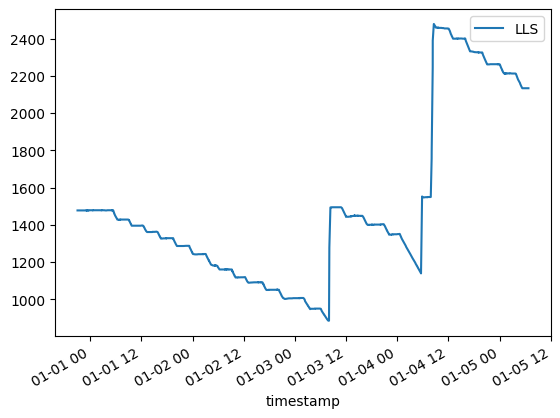

In [36]:
df_zap.plot(x='timestamp',  y='LLS')

stay
inc
stay
inc
stay
inc
stay
inc
stay


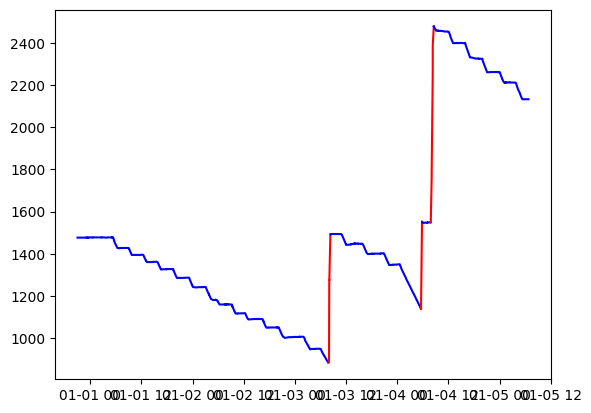

In [37]:
i = 0
while i < df_zap.shape[0] - 1:
    if df_zap.loc[i, 'fill_or_steal'] == 1:
        j = i
        while j < df_zap.shape[0] - 1 and df_zap.loc[j, 'fill_or_steal'] == 1:
            j += 1
        plt.plot(df_zap.loc[i:j, 'timestamp'], df_zap.loc[i:j, 'LLS'], color='red')
        i = j
        print('inc')
    else:
        j = i
        while j < df_zap.shape[0] - 1 and df_zap.loc[j, 'fill_or_steal'] == 0:
            j += 1
        plt.plot(df_zap.loc[i:j, 'timestamp'], df_zap.loc[i:j, 'LLS'], color='blue')
        i = j
        print('stay')

Предположим, чт о данный алгоритм корретктно отмечает заправки. Применим его теперь ко всем данным

## 3. Сделать 12 графиков по заправкам (с интерполяцией данных через [calib.csv](https://drive.google.com/file/d/1dfSIZUovWuKA0uUYAc80KgqKNwTpegGi/view?usp=sharing))

In [38]:
df_zap = df_zap2.copy()
df_zap = df_zap.sort_values(by='timestamp').reset_index(drop=True)

In [39]:
df_zap['less_than_10'] = True
df_zap['no_movement'] = True
i = 0
while i < df_zap.shape[0] - 1:
    if df_zap.loc[i, 'distant'] > 10.0:
        df_zap.loc[i, 'less_than_10'] = False
    if df_zap.loc[i, 'speed_calc'] > 5.0:
        df_zap.loc[i, 'no_movement'] = False
    if df_zap.loc[i, 'less_than_10'] == True and df_zap.loc[i, 'no_movement'] == True:
        fuel_df = df_zap[((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) < dt.timedelta(seconds=900)) & ((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) >= dt.timedelta(seconds=0))].copy()
        fuel_surpl = fuel_df.loc[fuel_df.index[1:], 'LLS'].max() - df_zap.loc[i, 'LLS']
        if fuel_surpl > 50 and fuel_df.loc[fuel_df.index[-1], 'LLS'] > df_zap.loc[i, 'LLS']:
            fin = fuel_df.index[-1]
            print(df_zap[((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) < dt.timedelta(seconds=900)) & ((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) >= dt.timedelta(seconds=0))].index)
            for j in df_zap[((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) < dt.timedelta(seconds=900)) & ((df_zap['timestamp'] - df_zap.loc[i, 'timestamp']) >= dt.timedelta(seconds=0))].index:
                df_zap.loc[j, 'fill_or_steal'] = 1
            i = j
    i += 1

Index([1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231], dtype='int64')
Index([1233, 1234, 1235], dtype='int64')
Index([1572, 1573, 1574, 1575], dtype='int64')
Index([1613, 1614, 1615, 1616], dtype='int64')
Index([1617, 1618], dtype='int64')
Index([1619, 1620, 1621, 1622], dtype='int64')
Index([3356, 3357, 3358, 3359, 3360, 3361, 3362], dtype='int64')
Index([4483, 4484, 4485, 4486, 4487, 4488, 4489, 4490, 4491, 4492, 4493, 4494,
       4495, 4496, 4497, 4498, 4499],
      dtype='int64')
Index([4500, 4501, 4502, 4503, 4504, 4505], dtype='int64')
Index([5058, 5059, 5060, 5061, 5062, 5063, 5064, 5065, 5066], dtype='int64')
Index([5067, 5068, 5069, 5070, 5071, 5072, 5073, 5074, 5075, 5076, 5077, 5078], dtype='int64')
Index([5251, 5252, 5253, 5254, 5255, 5256, 5257, 5258, 5259, 5260, 5261, 5262,
       5263, 5264, 5265, 5266, 5267, 5268],
      dtype='int64')
Index([5435, 5436, 5437, 5438, 5439, 5440, 5441, 5442, 5443, 5444, 5445, 5446,
       5447, 5448, 5449, 5450, 5451, 5452, 

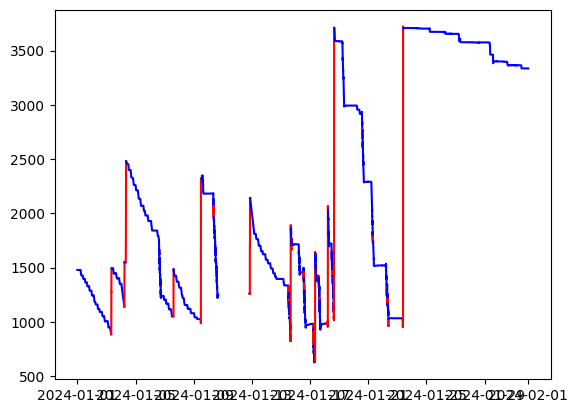

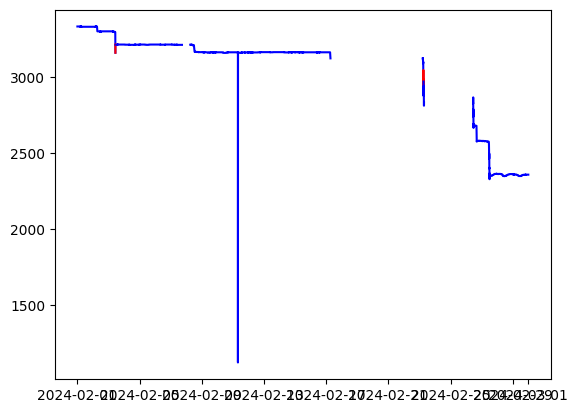

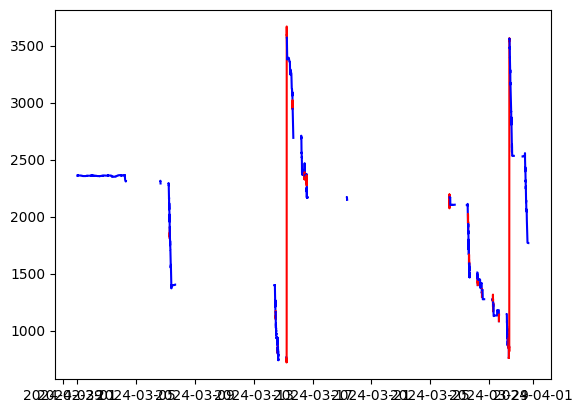

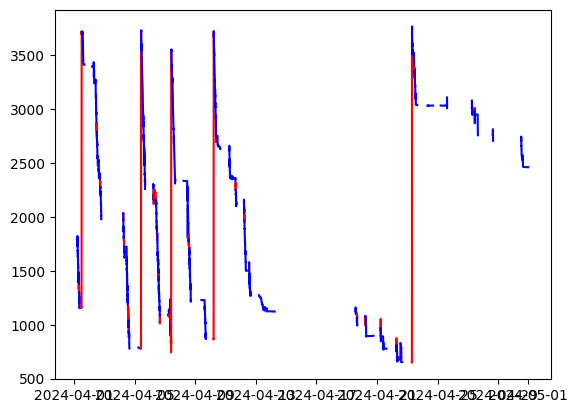

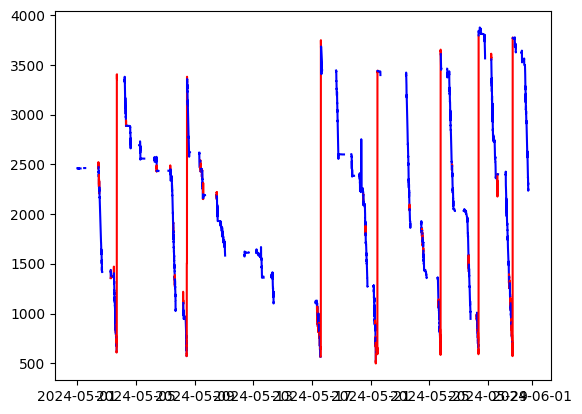

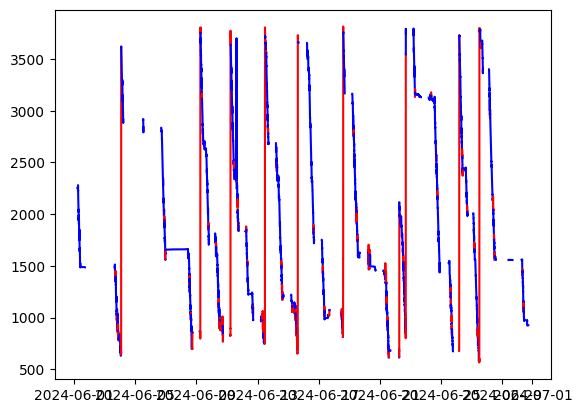

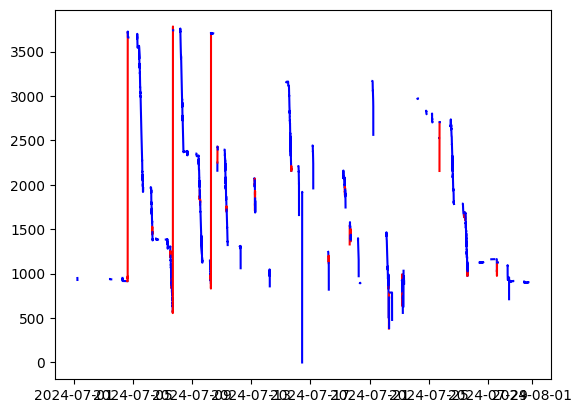

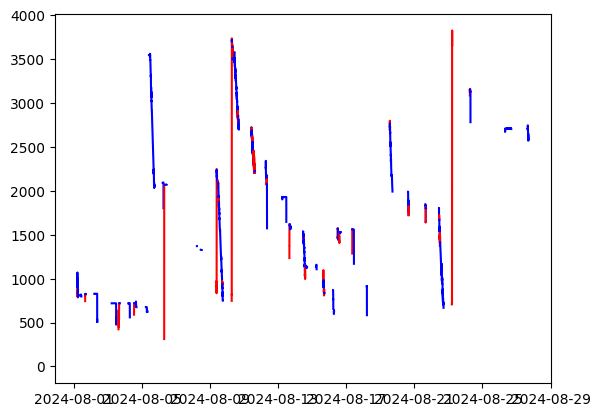

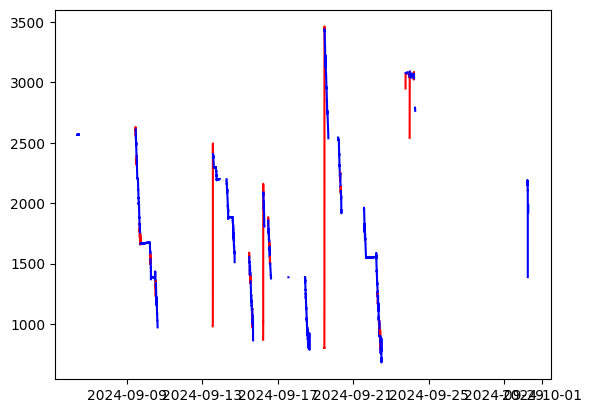

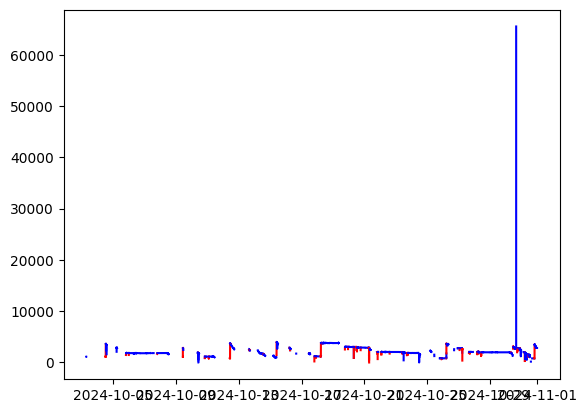

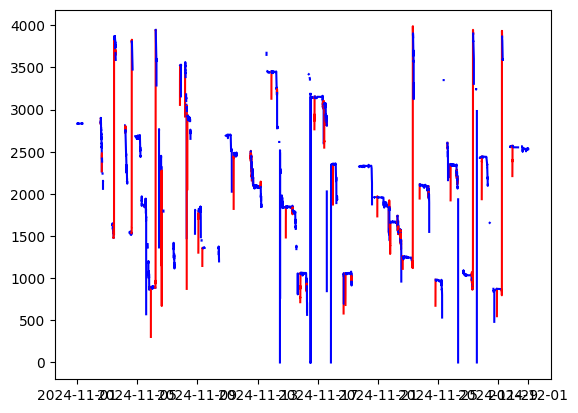

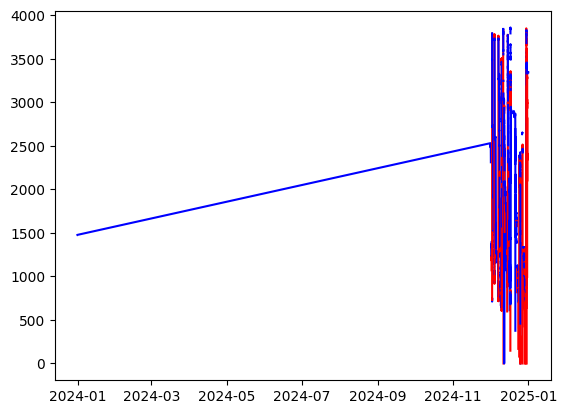

In [40]:
for i in range(1, 13):
    df_to_plot = df_zap[df_zap['timestamp'].dt.month == i]
    df_to_plot.reset_index(drop=True, inplace=True)
    while i < df_to_plot.shape[0] - 1:
        if df_to_plot.loc[i, 'fill_or_steal'] == 1:
            j = i
            while j < df_to_plot.shape[0] - 1 and df_to_plot.loc[j, 'fill_or_steal'] == 1:
                j += 1
            plt.plot(df_to_plot.loc[i:j, 'timestamp'], df_to_plot.loc[i:j, 'LLS'], color='red')
            i = j
        else:
            j = i
            while j < df_to_plot.shape[0] - 1 and df_to_plot.loc[j, 'fill_or_steal'] == 0:
                j += 1
            plt.plot(df_to_plot.loc[i:j, 'timestamp'], df_to_plot.loc[i:j, 'LLS'], color='blue')
            i = j
    plt.show()

Проведём аналогичные операции для второго датасета

In [41]:
df_zap_33 = pd.read_csv('zap_data_33.csv')

In [42]:
df_zap_33

,lat,lon,timestamp,speed,voltage,can_data
0,NaN,NaN,1708583447,NaN,11.545,"{""LLS_0"": 3020, ""xLLS_71"": 3020}"
1,NaN,NaN,1708583446,NaN,NaN,{}
2,55.803604,37.033916,1708583471,0.0,11.651,"{""LLS_0"": 3019, ""xLLS_71"": 3019}"
3,55.803604,37.033916,1708583521,0.0,11.660,"{""LLS_0"": 3019, ""xLLS_71"": 3019}"
4,55.803574,37.033821,1708583564,0.0,10.720,"{""LLS_0"": 3019, ""xLLS_71"": 3019}"
...,...,...,...,...,...,...
403461,55.664818,37.758133,1734427816,0.0,12.662,"{""3"": 55.664817810058594, ""4"": 37.758132934570..."
403462,55.664818,37.758133,1734427966,0.0,12.662,"{""3"": 55.664817810058594, ""4"": 37.758132934570..."
403463,55.664818,37.758133,1734428116,0.0,12.662,"{""3"": 55.664817810058594, ""4"": 37.758132934570..."
403464,55.664818,37.758133,1734428266,0.0,12.520,"{""3"": 55.664817810058594, ""4"": 37.758132934570..."


In [43]:
import json

# Сначала преобразуем строковые представления словарей в реальные словари Python
df_zap_33['data'] = df_zap_33['can_data'].apply(lambda x: json.loads(x))

# Теперь создаем новый столбец LLS, извлекая значение LLS_0
df_zap_33['LLS'] = df_zap_33['data'].apply(lambda x: x.get('LLS_0'))

# Если нужно, можно удалить промежуточный столбец data
df_zap_33.drop(columns=['data'], inplace=True)
df_zap_33.drop(columns=['can_data'], inplace=True)

In [44]:
df_zap_33

,lat,lon,timestamp,speed,voltage,LLS
0,NaN,NaN,1708583447,NaN,11.545,3020.0
1,NaN,NaN,1708583446,NaN,NaN,NaN
2,55.803604,37.033916,1708583471,0.0,11.651,3019.0
3,55.803604,37.033916,1708583521,0.0,11.660,3019.0
4,55.803574,37.033821,1708583564,0.0,10.720,3019.0
...,...,...,...,...,...,...
403461,55.664818,37.758133,1734427816,0.0,12.662,2293.0
403462,55.664818,37.758133,1734427966,0.0,12.662,2292.0
403463,55.664818,37.758133,1734428116,0.0,12.662,2291.0
403464,55.664818,37.758133,1734428266,0.0,12.520,2289.0


In [45]:
df_zap_33 = df_zap_33.dropna(subset=['LLS']).reset_index(drop=True)

In [46]:
df_zap_33

,lat,lon,timestamp,speed,voltage,LLS
0,NaN,NaN,1708583447,NaN,11.545,3020.0
1,55.803604,37.033916,1708583471,0.0,11.651,3019.0
2,55.803604,37.033916,1708583521,0.0,11.660,3019.0
3,55.803574,37.033821,1708583564,0.0,10.720,3019.0
4,55.803574,37.033821,1708583566,0.0,10.924,3019.0
...,...,...,...,...,...,...
403431,55.664818,37.758133,1734427816,0.0,12.662,2293.0
403432,55.664818,37.758133,1734427966,0.0,12.662,2292.0
403433,55.664818,37.758133,1734428116,0.0,12.662,2291.0
403434,55.664818,37.758133,1734428266,0.0,12.520,2289.0


In [47]:
df_zap_33['timestamp'] = pd.to_datetime(df_zap_33['timestamp'] * 1e9)

In [48]:
df_zap_33

,lat,lon,timestamp,speed,voltage,LLS
0,NaN,NaN,2024-02-22 06:30:47,NaN,11.545,3020.0
1,55.803604,37.033916,2024-02-22 06:31:11,0.0,11.651,3019.0
2,55.803604,37.033916,2024-02-22 06:32:01,0.0,11.660,3019.0
3,55.803574,37.033821,2024-02-22 06:32:44,0.0,10.720,3019.0
4,55.803574,37.033821,2024-02-22 06:32:46,0.0,10.924,3019.0
...,...,...,...,...,...,...
403431,55.664818,37.758133,2024-12-17 09:30:16,0.0,12.662,2293.0
403432,55.664818,37.758133,2024-12-17 09:32:46,0.0,12.662,2292.0
403433,55.664818,37.758133,2024-12-17 09:35:16,0.0,12.662,2291.0
403434,55.664818,37.758133,2024-12-17 09:37:46,0.0,12.520,2289.0


In [49]:
df_zap_33['fill_or_steal'] = 0

In [50]:
df_zap_33['fuel_surplus'] = False

In [51]:
for i in range(1, df_zap_33.shape[0]):
    if df_zap_33.loc[i, 'LLS'] > df_zap_33.loc[i - 1, 'LLS']:
        df_zap_33.loc[i, 'fuel_surplus'] = True

In [52]:
df_zap_33['distant'] = 0.0
for j in range(1, df_zap_33.shape[0]):
        df_zap_33.loc[j, 'distant'] = dist(df_zap_33.loc[j, 'lat'], df_zap_33.loc[j - 1, 'lat'], df_zap_33.loc[j, 'lon'], df_zap_33.loc[j - 1, 'lon'])

In [53]:
df_zap_33['speed_calc'] = 0.0
df_zap_33['seconds'] = 0.0
for j in range(1, df_zap_33.shape[0]):
    df_zap_33.loc[j, 'seconds'] = (df_zap_33.loc[j, 'timestamp'] - df_zap_33.loc[j - 1, 'timestamp']).seconds
df_zap_33['speed_calc'] = df_zap_33['distant'] / 1000.0 / (df_zap_33['seconds'] / 3600.0)

In [54]:
df_zap_33['fuel_diff'] = 0.0
for i in range(1, df_zap_33.shape[0]):
    df_zap_33.loc[i, 'fuel_diff'] = df_zap_33.loc[i, 'LLS'] - df_zap_33.loc[i - 1, 'LLS']

Предположим, что во время заправки для ТС характерно следующее:
1. Скорость околонулевая (меньше 5 км/ч допустим);
2. Координаты практически не меняются (возможны небольшие изменения, допустим в пределах 10 метров за счёт корректности работы датчиков GPS)
3. Топливо растёт в течение некоторого промежутка времени (допустим от 3 минут и не более 15 минут, иначе это скорее всего какое-то другое событие)
4. Также попробуем определеить по таким местам наличие именно заправок
5. Альтернативно третьему пункту можно предложить, что по итогам промежутка простоя количество топлива увеличилось.

In [55]:
df_zap_33 = df_zap_33.sort_values(by='timestamp').reset_index(drop=True)

In [56]:
df_zap_33['less_than_10'] = True
df_zap_33['no_movement'] = True
i = 0
while i < df_zap_33.shape[0] - 1:
    if df_zap_33.loc[i, 'distant'] > 10.0:
        df_zap_33.loc[i, 'less_than_10'] = False
    if df_zap_33.loc[i, 'speed_calc'] > 5.0:
        df_zap_33.loc[i, 'no_movement'] = False
    if df_zap_33.loc[i, 'less_than_10'] == True and df_zap_33.loc[i, 'no_movement'] == True:
        fuel_df = df_zap_33[((df_zap_33['timestamp'] - df_zap_33.loc[i, 'timestamp']) < dt.timedelta(seconds=900)) & ((df_zap_33['timestamp'] - df_zap_33.loc[i, 'timestamp']) >= dt.timedelta(seconds=0))].copy()
        fuel_surpl = fuel_df.loc[fuel_df.index[1:], 'LLS'].max() - df_zap_33.loc[i, 'LLS']
        if fuel_surpl > 50 and fuel_df.loc[fuel_df.index[-1], 'LLS'] > df_zap_33.loc[i, 'LLS']:
            fin = fuel_df.index[-1]
            print(df_zap_33[((df_zap_33['timestamp'] - df_zap_33.loc[i, 'timestamp']) < dt.timedelta(seconds=900)) & ((df_zap_33['timestamp'] - df_zap_33.loc[i, 'timestamp']) >= dt.timedelta(seconds=0))].index)
            for j in df_zap_33[((df_zap_33['timestamp'] - df_zap_33.loc[i, 'timestamp']) < dt.timedelta(seconds=900)) & ((df_zap_33['timestamp'] - df_zap_33.loc[i, 'timestamp']) >= dt.timedelta(seconds=0))].index:
                df_zap_33.loc[j, 'fill_or_steal'] = 1
            i = j
    i += 1

Index([79, 80, 81, 82, 83, 84, 85, 86], dtype='int64')
Index([2379, 2380, 2381, 2382, 2383, 2384, 2385, 2386, 2387, 2388, 2389, 2390,
       2391, 2392, 2393, 2394],
      dtype='int64')
Index([2615, 2616, 2617, 2618, 2619, 2620, 2621, 2622, 2623, 2624, 2625, 2626,
       2627, 2628, 2629, 2630, 2631, 2632, 2633, 2634, 2635, 2636, 2637, 2638,
       2639, 2640, 2641],
      dtype='int64')
Index([2725, 2726, 2727, 2728, 2729, 2730, 2731, 2732, 2733, 2734, 2735, 2736,
       2737, 2738, 2739, 2740],
      dtype='int64')
Index([2759, 2760, 2761, 2762, 2763, 2764, 2765, 2766, 2767, 2768, 2769, 2770,
       2771],
      dtype='int64')
Index([2772, 2773, 2774, 2775, 2776, 2777, 2778, 2779, 2780, 2781, 2782, 2783,
       2784, 2785, 2786, 2787, 2788, 2789, 2790, 2791, 2792, 2793, 2794, 2795,
       2796, 2797, 2798, 2799, 2800, 2801, 2802, 2803, 2804, 2805, 2806, 2807,
       2808, 2809, 2810, 2811],
      dtype='int64')
Index([2964, 2965, 2966, 2967, 2968, 2969, 2970, 2971, 2972, 2973, 2974]

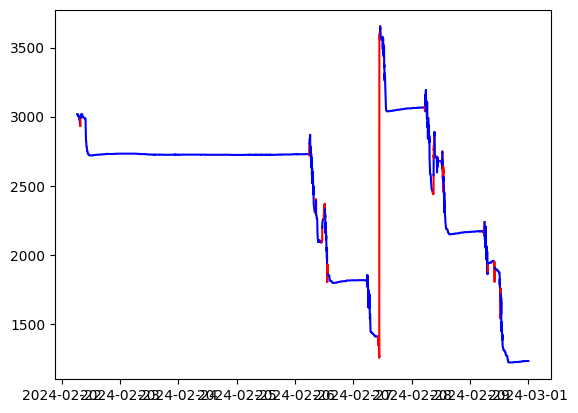

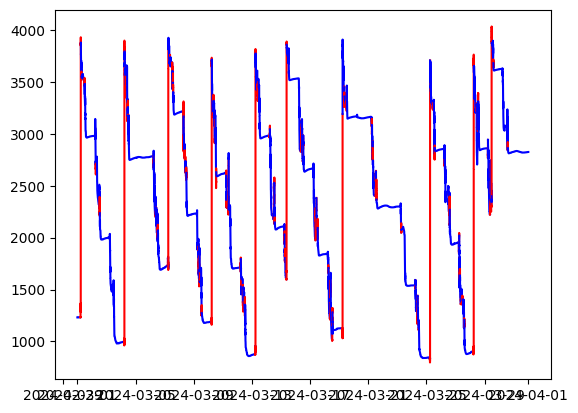

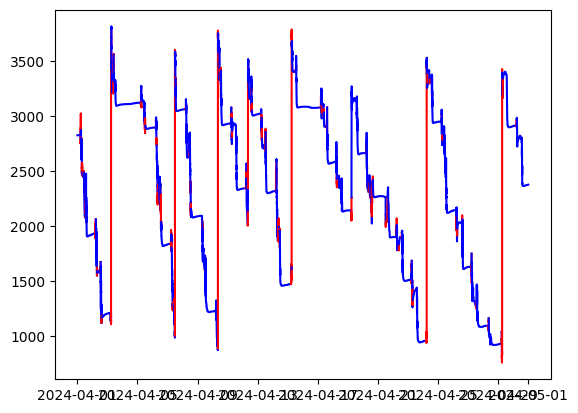

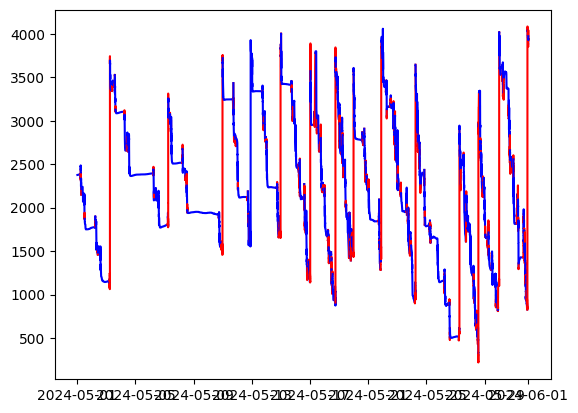

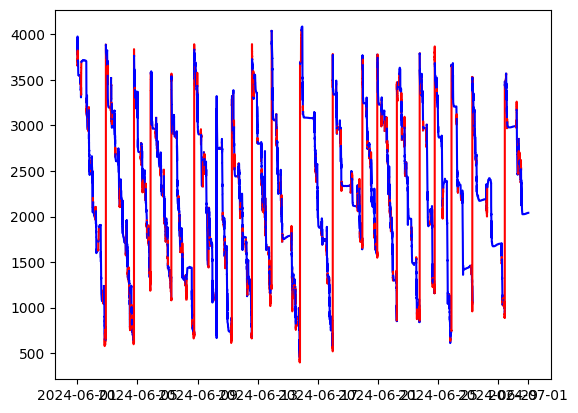

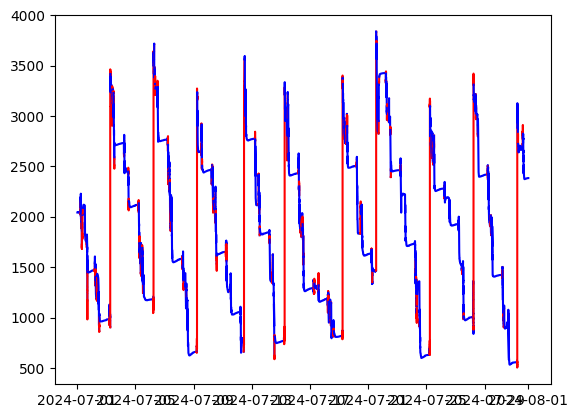

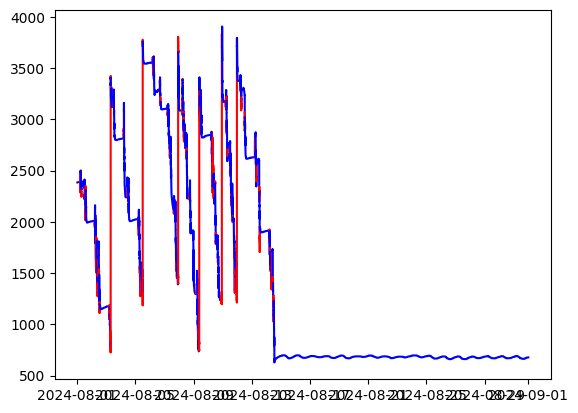

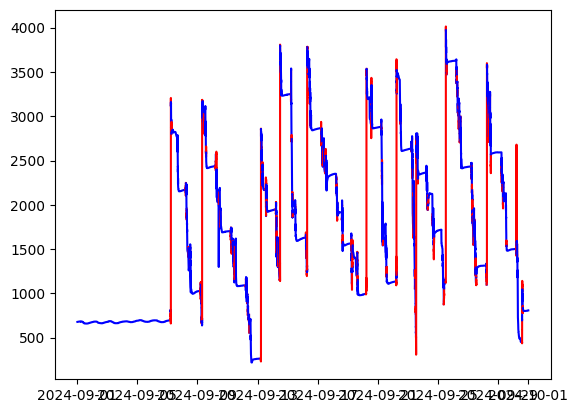

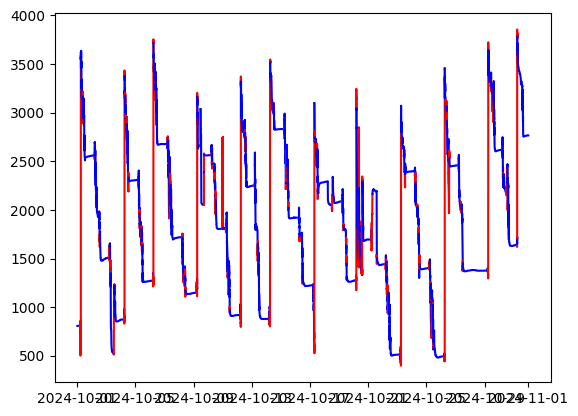

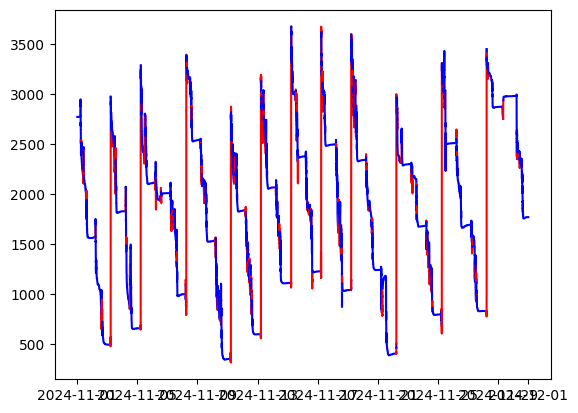

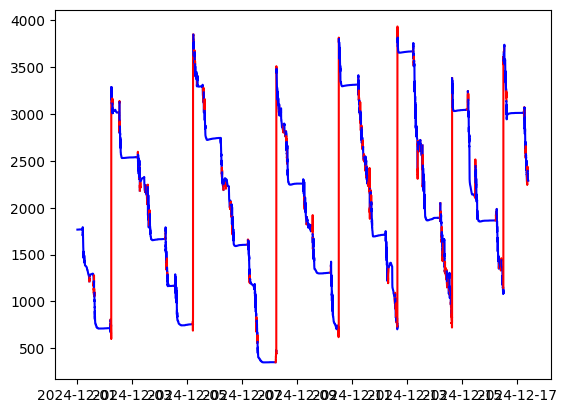

In [57]:
for i in range(1, 13):
    df_to_plot = df_zap_33[df_zap_33['timestamp'].dt.month == i]
    df_to_plot.reset_index(drop=True, inplace=True)
    while i < df_to_plot.shape[0] - 1:
        if df_to_plot.loc[i, 'fill_or_steal'] == 1:
            j = i
            while j < df_to_plot.shape[0] - 1 and df_to_plot.loc[j, 'fill_or_steal'] == 1:
                j += 1
            plt.plot(df_to_plot.loc[i:j, 'timestamp'], df_to_plot.loc[i:j, 'LLS'], color='red')
            i = j
        else:
            j = i
            while j < df_to_plot.shape[0] - 1 and df_to_plot.loc[j, 'fill_or_steal'] == 0:
                j += 1
            plt.plot(df_to_plot.loc[i:j, 'timestamp'], df_to_plot.loc[i:j, 'LLS'], color='blue')
            i = j
    plt.show()